# Actividad 2: Procesamiento de Datos en Infraestructura Cloud
## Unidad 3 - Evidencia de Aprendizaje (EA3)

**Objetivo:** Diseñar, desplegar y procesar un conjunto de datos en Databricks Community Edition utilizando Apache Spark.

---

## 1. Diseño del Esquema de Datos

### 1.1 Descripción del Dataset
**Dataset seleccionado:** Online Retail Dataset (UCI Machine Learning Repository / Kaggle)

**Entidades principales:**
- **Transacciones de ventas:** Contiene información de compras online realizadas entre 2010-2011
- **Productos:** Artículos vendidos con descripciones
- **Clientes:** Identificadores únicos de clientes
- **Ubicaciones:** Países donde se realizaron las ventas

### 1.2 Diccionario de Datos

| Campo | Tipo de Dato | Descripción | Ejemplo | Nulable | Clave |
|-------|--------------|-------------|---------|---------|-------|
| InvoiceNo | String | Número de factura único (6 dígitos) | "536365" | No | PK |
| StockCode | String | Código único del producto | "85123A" | No | FK |
| Description | String | Descripción del producto | "WHITE HANGING HEART" | Sí | - |
| Quantity | Integer | Cantidad de productos por transacción | 6 | No | - |
| InvoiceDate | Timestamp | Fecha y hora de la transacción | "2010-12-01 08:26:00" | No | - |
| UnitPrice | Double | Precio unitario del producto en GBP | 2.55 | No | - |
| CustomerID | Integer | Identificador único del cliente | 17850 | Sí | FK |
| Country | String | País donde reside el cliente | "United Kingdom" | No | - |

**Tipos de Datos:**
- **String (StringType):** Campos de texto variable
- **Integer (IntegerType):** Valores numéricos enteros
- **Double (DoubleType):** Valores numéricos con decimales
- **Timestamp (TimestampType):** Fecha y hora combinadas

**Consideraciones:**
- `InvoiceNo` es la clave primaria de cada transacción
- `CustomerID` permite nulables debido a transacciones sin cliente registrado
- `Description` puede ser nulo en productos sin descripción completa


In [0]:
# Importar librerías necesarias
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType

# Definición del esquema usando StructType
schema_online_retail = StructType([
    StructField("InvoiceNo", StringType(), nullable=False),
    StructField("StockCode", StringType(), nullable=False),
    StructField("Description", StringType(), nullable=True),
    StructField("Quantity", IntegerType(), nullable=False),
    StructField("InvoiceDate", TimestampType(), nullable=False),
    StructField("UnitPrice", DoubleType(), nullable=False),
    StructField("CustomerID", IntegerType(), nullable=True),
    StructField("Country", StringType(), nullable=False)
])

# Mostrar el esquema definido
print("Esquema definido usando StructType:")
print(schema_online_retail)
print("\n")
print("Campos del esquema:")
for field in schema_online_retail.fields:
    print(f"- {field.name}: {field.dataType} (Nullable: {field.nullable})")


Esquema definido usando StructType:
StructType([StructField('InvoiceNo', StringType(), False), StructField('StockCode', StringType(), False), StructField('Description', StringType(), True), StructField('Quantity', IntegerType(), False), StructField('InvoiceDate', TimestampType(), False), StructField('UnitPrice', DoubleType(), False), StructField('CustomerID', IntegerType(), True), StructField('Country', StringType(), False)])


Campos del esquema:
- InvoiceNo: StringType() (Nullable: False)
- StockCode: StringType() (Nullable: False)
- Description: StringType() (Nullable: True)
- Quantity: IntegerType() (Nullable: False)
- InvoiceDate: TimestampType() (Nullable: False)
- UnitPrice: DoubleType() (Nullable: False)
- CustomerID: IntegerType() (Nullable: True)
- Country: StringType() (Nullable: False)


In [0]:
# Definición del esquema usando DDL
ddl_schema = """
    InvoiceNo STRING NOT NULL,
    StockCode STRING NOT NULL,
    Description STRING,
    Quantity INT NOT NULL,
    InvoiceDate TIMESTAMP NOT NULL,
    UnitPrice DOUBLE NOT NULL,
    CustomerID INT,
    Country STRING NOT NULL
"""

# Crear el esquema desde DDL
from pyspark.sql.types import StructType
schema_from_ddl = StructType.fromDDL(ddl_schema)

print("Esquema definido usando DDL:")
print(schema_from_ddl)


Esquema definido usando DDL:
StructType([StructField('InvoiceNo', StringType(), False), StructField('StockCode', StringType(), False), StructField('Description', StringType(), True), StructField('Quantity', IntegerType(), False), StructField('InvoiceDate', TimestampType(), False), StructField('UnitPrice', DoubleType(), False), StructField('CustomerID', IntegerType(), True), StructField('Country', StringType(), False)])


### 1.3 Justificación del Diseño del Esquema

**Decisiones de diseño:**

1. **Uso de StructType vs DDL:**
   - StructType proporciona control programático completo y validación en tiempo de desarrollo
   - DDL es más conciso y legible para esquemas simples
   - Ambos enfoques son válidos en entornos productivos de Big Data

2. **Tipos de datos seleccionados:**
   - `StringType` para identificadores alfanuméricos que no requieren operaciones matemáticas
   - `IntegerType` para cantidades y IDs numéricos
   - `DoubleType` para precios con precisión decimal
   - `TimestampType` para fechas con componente temporal completo

3. **Manejo de nulabilidad:**
   - `CustomerID` nullable: transacciones anónimas o de invitados
   - `Description` nullable: productos sin descripción completa en el sistema
   - Campos críticos (InvoiceNo, Quantity, UnitPrice) marcados como NOT NULL

4. **Escalabilidad:**
   - El esquema soporta particionamiento por `InvoiceDate` o `Country`
   - Permite agregaciones eficientes por cliente, producto o región
   - Estructura óptima para consultas analíticas OLAP


---

## 2. Configuración y Despliegue en Databricks Community Edition

### 2.1 Información del Entorno Databricks

A continuación se presenta la configuración completa del entorno cloud donde se procesarán los datos.


In [0]:
# EVIDENCIA 1: Informacion del Cluster y Runtime de Databricks

import sys
import platform

print("="*70)
print("CONFIGURACION DEL ENTORNO DATABRICKS COMMUNITY EDITION")
print("="*70)
print()

# Version de Databricks Runtime
print("DATABRICKS RUNTIME")
print("-" * 70)
try:
    notebook_path = dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get()
    print(f"Entorno: Databricks Community Edition (Serverless)")
    print(f"Notebook Path: {notebook_path}")
except:
    print("Ejecutando en Databricks Community Edition")

print()

# Version de Python
print("PYTHON")
print("-" * 70)
print(f"Version de Python: {sys.version}")
print(f"Version de Python (corta): {platform.python_version()}")
print(f"Implementacion: {platform.python_implementation()}")
print()

# Version de Apache Spark
print("APACHE SPARK")
print("-" * 70)
print(f"Version de Spark: {spark.version}")

# Para serverless, obtenemos info de forma alternativa
try:
    app_name = spark.conf.get("spark.app.name", "N/A")
    print(f"Application Name: {app_name}")
except:
    print("Application Name: Databricks Serverless Session")

# Tipo de entorno
print(f"Modo de Ejecucion: Serverless Compute")
print()


CONFIGURACION DEL ENTORNO DATABRICKS COMMUNITY EDITION

DATABRICKS RUNTIME
----------------------------------------------------------------------
Entorno: Databricks Community Edition (Serverless)
Notebook Path: /Users/jesus.gonzalezc@est.iudigital.edu.co/Gonzalez_Jesus_Actividad3

PYTHON
----------------------------------------------------------------------
Version de Python: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Version de Python (corta): 3.12.3
Implementacion: CPython

APACHE SPARK
----------------------------------------------------------------------
Version de Spark: 4.0.0
Application Name: Databricks Serverless Session
Modo de Ejecucion: Serverless Compute



In [0]:
# EVIDENCIA 2: Configuracion Detallada de Spark

print("="*70)
print("CONFIGURACION DETALLADA DE SPARK")
print("="*70)
print()

# En serverless, obtenemos configuracion mediante spark.conf
print("CONFIGURACIONES DE SPARK:")
print("-" * 70)
print()

# Configuraciones clave organizadas por categoria
configuraciones_clave = {
    "Cluster y Recursos": [
        "spark.master",
        "spark.submit.deployMode",
        "spark.app.name",
        "spark.databricks.clusterUsageTags.clusterEdition"
    ],
    "Memoria y Ejecutores": [
        "spark.executor.memory",
        "spark.driver.memory",
        "spark.executor.cores",
        "spark.driver.cores"
    ],
    "SQL y Optimizacion": [
        "spark.sql.adaptive.enabled",
        "spark.sql.adaptive.coalescePartitions.enabled",
        "spark.sql.shuffle.partitions"
    ],
    "Databricks Especifico": [
        "spark.databricks.service.port",
        "spark.databricks.cloudProvider"
    ]
}

for categoria, configs in configuraciones_clave.items():
    print(f"{categoria}:")
    for config_key in configs:
        try:
            valor = spark.conf.get(config_key)
            print(f"  {config_key}: {valor}")
        except:
            print(f"  {config_key}: No disponible en serverless")
    print()

# Mostrar todas las configuraciones disponibles
print("="*70)
print("TODAS LAS CONFIGURACIONES DISPONIBLES")
print("="*70)

# Obtener configuraciones usando getAll() de forma segura
try:
    # En serverless, intentamos obtener configs sin acceder a sparkContext
    all_configs = []
    
    # Lista de configuraciones comunes a verificar
    config_keys = [
        "spark.app.id", "spark.app.name", "spark.master",
        "spark.sql.warehouse.dir", "spark.sql.catalogImplementation",
        "spark.sql.adaptive.enabled", "spark.sql.shuffle.partitions",
        "spark.executor.memory", "spark.driver.memory",
        "spark.databricks.clusterUsageTags.clusterEdition"
    ]
    
    for key in config_keys:
        try:
            value = spark.conf.get(key)
            all_configs.append((key, value))
        except:
            pass
    
    for key, value in sorted(all_configs):
        print(f"{key}: {value}")
    
    print(f"\nTotal de configuraciones obtenidas: {len(all_configs)}")
    
except Exception as e:
    print(f"Limitacion de serverless: {str(e)}")
    print("En serverless compute, el acceso a configuraciones JVM esta restringido")

print()


CONFIGURACION DETALLADA DE SPARK

CONFIGURACIONES DE SPARK:
----------------------------------------------------------------------

Cluster y Recursos:
  spark.master: No disponible en serverless
  spark.submit.deployMode: No disponible en serverless
  spark.app.name: No disponible en serverless
  spark.databricks.clusterUsageTags.clusterEdition: No disponible en serverless

Memoria y Ejecutores:
  spark.executor.memory: No disponible en serverless
  spark.driver.memory: No disponible en serverless
  spark.executor.cores: No disponible en serverless
  spark.driver.cores: No disponible en serverless

SQL y Optimizacion:
  spark.sql.adaptive.enabled: No disponible en serverless
  spark.sql.adaptive.coalescePartitions.enabled: No disponible en serverless
  spark.sql.shuffle.partitions: auto

Databricks Especifico:
  spark.databricks.service.port: No disponible en serverless
  spark.databricks.cloudProvider: No disponible en serverless

TODAS LAS CONFIGURACIONES DISPONIBLES
spark.sql.shuff

In [0]:
# EVIDENCIA 3: Recursos del Cluster (CPU, Memoria)

print("="*70)
print("RECURSOS DEL CLUSTER SERVERLESS")
print("="*70)
print()

# Configuracion de Executors
print("EXECUTORS (Nodos de Procesamiento):")
print("-" * 70)

try:
    executor_memory = spark.conf.get("spark.executor.memory")
    print(f"Memoria por Executor: {executor_memory}")
except:
    print(f"Memoria por Executor: Asignacion dinamica (serverless)")

try:
    executor_cores = spark.conf.get("spark.executor.cores")
    print(f"Nucleos por Executor: {executor_cores}")
except:
    print(f"Nucleos por Executor: Asignacion dinamica (serverless)")

print(f"Numero de Executors: Escalado automatico por Databricks")
print()

# Configuracion de Driver
print("DRIVER (Nodo Coordinador):")
print("-" * 70)

try:
    driver_memory = spark.conf.get("spark.driver.memory")
    print(f"Memoria del Driver: {driver_memory}")
except:
    print(f"Memoria del Driver: Asignacion dinamica (serverless)")

try:
    driver_cores = spark.conf.get("spark.driver.cores")
    print(f"Nucleos del Driver: {driver_cores}")
except:
    print(f"Nucleos del Driver: Asignacion dinamica (serverless)")

print()

# Autoscaling
print("AUTOSCALING Y ESCALABILIDAD:")
print("-" * 70)
print("Autoscaling: HABILITADO (nativo en serverless compute)")
print("  - Serverless escala automaticamente segun la carga")
print("  - No requiere configuracion manual de recursos")
print("  - Optimizacion de costos mediante escalado dinamico")
print()

# Informacion adicional
print("INFORMACION ADICIONAL:")
print("-" * 70)

# Default parallelism
try:
    shuffle_partitions = spark.conf.get("spark.sql.shuffle.partitions")
    print(f"SQL Shuffle Partitions: {shuffle_partitions}")
except:
    print(f"SQL Shuffle Partitions: 200 (valor por defecto)")

# Edicion del cluster
try:
    cluster_edition = spark.conf.get("spark.databricks.clusterUsageTags.clusterEdition")
    print(f"Edicion del Cluster: {cluster_edition.upper()}")
except:
    print(f"Edicion del Cluster: COMMUNITY (SERVERLESS)")

print()
print("NOTA: Databricks Serverless gestiona recursos automaticamente")
print("      sin necesidad de configuracion manual de cluster")


RECURSOS DEL CLUSTER SERVERLESS

EXECUTORS (Nodos de Procesamiento):
----------------------------------------------------------------------
Memoria por Executor: Asignacion dinamica (serverless)
Nucleos por Executor: Asignacion dinamica (serverless)
Numero de Executors: Escalado automatico por Databricks

DRIVER (Nodo Coordinador):
----------------------------------------------------------------------
Memoria del Driver: Asignacion dinamica (serverless)
Nucleos del Driver: Asignacion dinamica (serverless)

AUTOSCALING Y ESCALABILIDAD:
----------------------------------------------------------------------
Autoscaling: HABILITADO (nativo en serverless compute)
  - Serverless escala automaticamente segun la carga
  - No requiere configuracion manual de recursos
  - Optimizacion de costos mediante escalado dinamico

INFORMACION ADICIONAL:
----------------------------------------------------------------------
SQL Shuffle Partitions: auto
Edicion del Cluster: COMMUNITY (SERVERLESS)

NOTA: Da

In [0]:
# EVIDENCIA 4: Sistema de Almacenamiento en Databricks Serverless

print("="*70)
print("SISTEMA DE ALMACENAMIENTO EN DATABRICKS SERVERLESS")
print("="*70)
print()

print("INFORMACION DE ALMACENAMIENTO:")
print("-" * 70)
print("Databricks Serverless usa Unity Catalog y tablas gestionadas")
print("Acceso a DBFS publico esta completamente deshabilitado")
print("Los datos se almacenan directamente como tablas Delta Lake")
print()

# Listar directorios disponibles (solo lectura)
print("ESTRUCTURA DE DIRECTORIOS DISPONIBLES (SOLO LECTURA):")
print("-" * 70)

try:
    dbfs_root = dbutils.fs.ls("/")
    
    for item in dbfs_root:
        tipo = "[DIR]" if item.isDir() else "[FILE]"
        tamano = f"{item.size / (1024**2):.2f} MB" if item.size > 0 else "0 KB"
        print(f"{tipo:8} | {item.name:<35} | {tamano}")
    
    print()
    
except Exception as e:
    print(f"Error al listar directorios: {e}")
    print()


# Verificar databricks-datasets disponibles
print("="*70)
print("DATASETS DE EJEMPLO DISPONIBLES PARA LA ACTIVIDAD")
print("="*70)

try:
    datasets = dbutils.fs.ls("/databricks-datasets/")
    print(f"Total de datasets disponibles: {len(datasets)}")
    print()
    
    # Buscar datasets utiles para la actividad
    print("Datasets recomendados (primeros 10):")
    print("-" * 70)
    
    for i, ds in enumerate(datasets[:10], 1):
        tipo = "[DIR]" if ds.isDir() else "[FILE]"
        print(f"{i:2}. {tipo} {ds.name}")
    
    print()
    
    # Explorar un dataset especifico (COVID como ejemplo)
    print("Explorando dataset: /databricks-datasets/COVID/")
    print("-" * 70)
    
    try:
        covid_files = dbutils.fs.ls("/databricks-datasets/COVID/")
        for file in covid_files[:5]:
            tipo = "[DIR]" if file.isDir() else "[FILE]"
            tamano = f"{file.size / (1024**2):.2f} MB" if file.size > 0 else "0 KB"
            print(f"  {tipo} {file.name:<40} {tamano}")
    except:
        print("  Dataset no accesible o vacio")
    
    print()
    
except Exception as e:
    print(f"Error al listar datasets: {e}")

print()
print("="*70)
print("ESTRATEGIA FINAL:")
print("="*70)
print("- Origen de datos: /databricks-datasets/ (datasets precargados)")
print("- Procesamiento: DataFrames de Spark en memoria")
print("- Almacenamiento: Tablas Delta Lake gestionadas")
print("- No se requiere acceso a DBFS para crear directorios")
print()
print("Esta estrategia es compatible con Databricks Serverless")
print("y cumple con todos los requisitos de la actividad.")


SISTEMA DE ALMACENAMIENTO EN DATABRICKS SERVERLESS

INFORMACION DE ALMACENAMIENTO:
----------------------------------------------------------------------
Databricks Serverless usa Unity Catalog y tablas gestionadas
Acceso a DBFS publico esta completamente deshabilitado
Los datos se almacenan directamente como tablas Delta Lake

ESTRUCTURA DE DIRECTORIOS DISPONIBLES (SOLO LECTURA):
----------------------------------------------------------------------
[DIR]    | Volumes/                            | 0 KB
[DIR]    | Workspace/                          | 0 KB
[DIR]    | databricks-datasets/                | 0 KB

DATASETS DE EJEMPLO DISPONIBLES PARA LA ACTIVIDAD
Total de datasets disponibles: 55

Datasets recomendados (primeros 10):
----------------------------------------------------------------------
 1. [DIR] COVID/
 2. [FILE] README.md
 3. [DIR] Rdatasets/
 4. [FILE] SPARK_README.md
 5. [DIR] adult/
 6. [DIR] airlines/
 7. [DIR] amazon/
 8. [DIR] asa/
 9. [DIR] atlas_higgs/
10. [DIR] 

In [0]:
# EVIDENCIA 5: Bibliotecas y Dependencias Disponibles

print("="*70)
print("BIBLIOTECAS Y DEPENDENCIAS")
print("="*70)
print()

# Importar bibliotecas clave de Big Data
import pyspark
import pandas as pd
import numpy as np

print("BIBLIOTECAS DE BIG DATA:")
print("-" * 70)
print(f"PySpark: {pyspark.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print()

# Modulos de PySpark disponibles
print("MODULOS DE PYSPARK DISPONIBLES:")
print("-" * 70)
modulos = [
    "pyspark.sql",
    "pyspark.sql.functions",
    "pyspark.sql.types",
    "pyspark.ml",
    "pyspark.streaming"
]

for modulo in modulos:
    try:
        __import__(modulo)
        print(f"[OK] {modulo}")
    except ImportError:
        print(f"[X]  {modulo} (no disponible)")

print()
print("Entorno configurado correctamente para procesamiento Big Data")
print("Serverless Compute: Listo para procesamiento escalable")


BIBLIOTECAS Y DEPENDENCIAS

BIBLIOTECAS DE BIG DATA:
----------------------------------------------------------------------
PySpark: 4.0.0
Pandas: 2.2.3
NumPy: 2.1.3

MODULOS DE PYSPARK DISPONIBLES:
----------------------------------------------------------------------
[OK] pyspark.sql
[OK] pyspark.sql.functions
[OK] pyspark.sql.types
[OK] pyspark.ml
[OK] pyspark.streaming

Entorno configurado correctamente para procesamiento Big Data
Serverless Compute: Listo para procesamiento escalable


---

## 3. Obtencion e Ingestion de Datos desde Kaggle

### 3.1 Fuente de Datos

**Dataset:** Online Retail Dataset
**Fuente:** Kaggle - UCI Machine Learning Repository
**URL:** https://www.kaggle.com/datasets/abhishekrp1517/online-retail-transactions-dataset
**Formato:** CSV (aprox. 540,000 registros)

**Metodo de carga:**
- Descarga manual del archivo CSV desde Kaggle
- Upload mediante interfaz web de Databricks (New > Add or upload data)
- Creacion automatica de tabla Delta Lake en Unity Catalog


In [0]:
# EVIDENCIA 1: Verificacion de Tabla Cargada


print("="*70)
print("VERIFICACION DE DATOS CARGADOS")
print("="*70)
print()

# Ruta correcta de la tabla subida
tabla_cargada = "workspace.default.online_retail_raw"

print(f"Tabla cargada: {tabla_cargada}")
print()

# Verificar que la tabla existe
try:
    # Leer la tabla
    df_raw = spark.table(tabla_cargada)
    
    print("[OK] Tabla encontrada exitosamente")
    print()
    
    # Mostrar informacion basica
    print("INFORMACION BASICA DEL DATASET:")
    print("-" * 70)
    print(f"Numero de registros: {df_raw.count():,}")
    print(f"Numero de columnas: {len(df_raw.columns)}")
    print()
    
    # Mostrar columnas detectadas
    print("COLUMNAS DETECTADAS:")
    print("-" * 70)
    for col_name in df_raw.columns:
        print(f"  - {col_name}")
    print()
    
    # Mostrar primeras filas
    print("VISTA PREVIA DE DATOS (5 registros):")
    print("-" * 70)
    df_raw.show(5, truncate=False)
    
except Exception as e:
    print(f"[ERROR] No se pudo leer la tabla: {e}")
    print()
    print("SOLUCION:")
    print("1. Verifica que subiste el archivo correctamente")
    print("2. Actualiza la variable 'tabla_cargada' con la ruta correcta")
    print("3. Formato esperado: catalog.schema.table_name")


VERIFICACION DE DATOS CARGADOS

Tabla cargada: workspace.default.online_retail_raw

[OK] Tabla encontrada exitosamente

INFORMACION BASICA DEL DATASET:
----------------------------------------------------------------------
Numero de registros: 541,909
Numero de columnas: 8

COLUMNAS DETECTADAS:
----------------------------------------------------------------------
  - InvoiceNo
  - StockCode
  - Description
  - Quantity
  - InvoiceDate
  - UnitPrice
  - CustomerID
  - Country

VISTA PREVIA DE DATOS (5 registros):
----------------------------------------------------------------------
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART 

In [0]:
# EVIDENCIA 2: Aplicar Esquema Disenado y Crear Tabla Final

from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
from pyspark.sql.functions import col, to_timestamp

print("="*70)
print("APLICACION DEL ESQUEMA DISENADO")
print("="*70)
print()

# Recuperar esquema definido en Pestana 1
schema_online_retail = StructType([
    StructField("InvoiceNo", StringType(), nullable=False),
    StructField("StockCode", StringType(), nullable=False),
    StructField("Description", StringType(), nullable=True),
    StructField("Quantity", IntegerType(), nullable=False),
    StructField("InvoiceDate", TimestampType(), nullable=False),
    StructField("UnitPrice", DoubleType(), nullable=False),
    StructField("CustomerID", IntegerType(), nullable=True),
    StructField("Country", StringType(), nullable=False)
])

print("ESQUEMA A APLICAR:")
print("-" * 70)
for field in schema_online_retail.fields:
    nullable_str = "NULL" if field.nullable else "NOT NULL"
    print(f"  - {field.name}: {field.dataType.simpleString()} ({nullable_str})")
print()

# Leer datos RAW
df_raw = spark.table(tabla_cargada)

print("TRANSFORMACION Y LIMPIEZA DE DATOS:")
print("-" * 70)

# Aplicar transformaciones y casteos
df_transformed = df_raw.select(
    col("InvoiceNo").cast(StringType()).alias("InvoiceNo"),
    col("StockCode").cast(StringType()).alias("StockCode"),
    col("Description").cast(StringType()).alias("Description"),
    col("Quantity").cast(IntegerType()).alias("Quantity"),
    to_timestamp(col("InvoiceDate"), "M/d/yyyy H:mm").alias("InvoiceDate"),
    col("UnitPrice").cast(DoubleType()).alias("UnitPrice"),
    col("CustomerID").cast(IntegerType()).alias("CustomerID"),
    col("Country").cast(StringType()).alias("Country")
)

print("[OK] Transformaciones aplicadas")
print()

# Validar datos transformados
print("VALIDACION POST-TRANSFORMACION:")
print("-" * 70)
print(f"Registros totales: {df_transformed.count():,}")
print()

# Mostrar esquema final
print("ESQUEMA FINAL APLICADO:")
print("-" * 70)
df_transformed.printSchema()
print()

# Mostrar muestra de datos transformados
print("MUESTRA DE DATOS TRANSFORMADOS (5 registros):")
print("-" * 70)
df_transformed.show(5, truncate=False)


APLICACION DEL ESQUEMA DISENADO

ESQUEMA A APLICAR:
----------------------------------------------------------------------
  - InvoiceNo: string (NOT NULL)
  - StockCode: string (NOT NULL)
  - Description: string (NULL)
  - Quantity: int (NOT NULL)
  - InvoiceDate: timestamp (NOT NULL)
  - UnitPrice: double (NOT NULL)
  - CustomerID: int (NULL)
  - Country: string (NOT NULL)

TRANSFORMACION Y LIMPIEZA DE DATOS:
----------------------------------------------------------------------
[OK] Transformaciones aplicadas

VALIDACION POST-TRANSFORMACION:
----------------------------------------------------------------------
Registros totales: 541,909

ESQUEMA FINAL APLICADO:
----------------------------------------------------------------------
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = tru

In [0]:
# EVIDENCIA 3: Persistencia de Tabla Final

print("="*70)
print("PERSISTENCIA DE TABLA EN UNITY CATALOG")
print("="*70)
print()

# Nombre de la tabla final (usando workspace catalog)
tabla_final = "workspace.default.online_retail"

print(f"Tabla destino: {tabla_final}")
print()

# Guardar tabla con esquema correcto
print("Guardando tabla en formato Delta Lake...")
print("-" * 70)

try:
    df_transformed.write \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .saveAsTable(tabla_final)
    
    print(f"[OK] Tabla '{tabla_final}' creada exitosamente")
    print()
    
    # Verificar creacion
    df_final = spark.table(tabla_final)
    
    print("CONFIRMACION DE CREACION:")
    print("-" * 70)
    print(f"Registros en tabla final: {df_final.count():,}")
    print(f"Ubicacion: Unity Catalog (workspace) - Delta Lake")
    print(f"Formato: Delta (versionado y ACID)")
    print()
    
    # Estadisticas basicas
    print("ESTADISTICAS BASICAS:")
    print("-" * 70)
    
    # Contar nulos por columna
    from pyspark.sql.functions import sum as spark_sum, when, count
    
    null_counts = df_final.select([
        spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) 
        for c in df_final.columns
    ])
    
    print("Registros nulos por columna:")
    null_counts.show()
    
    # Registros unicos
    print(f"Facturas unicas: {df_final.select('InvoiceNo').distinct().count():,}")
    print(f"Productos unicos: {df_final.select('StockCode').distinct().count():,}")
    print(f"Clientes unicos: {df_final.select('CustomerID').dropna().distinct().count():,}")
    print(f"Paises unicos: {df_final.select('Country').distinct().count():,}")
    
except Exception as e:
    print(f"[ERROR] Error al guardar tabla: {e}")


PERSISTENCIA DE TABLA EN UNITY CATALOG

Tabla destino: workspace.default.online_retail

Guardando tabla en formato Delta Lake...
----------------------------------------------------------------------
[OK] Tabla 'workspace.default.online_retail' creada exitosamente

CONFIRMACION DE CREACION:
----------------------------------------------------------------------
Registros en tabla final: 541,909
Ubicacion: Unity Catalog (workspace) - Delta Lake
Formato: Delta (versionado y ACID)

ESTADISTICAS BASICAS:
----------------------------------------------------------------------
Registros nulos por columna:
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|         0|      0|
+---------+---------+-----------+--------+-----------+-----

In [0]:
%sql
-- EVIDENCIA 4: Descripcion de Tabla con SQL

-- Describir estructura de la tabla
DESCRIBE EXTENDED workspace.default.online_retail;


col_name,data_type,comment
InvoiceNo,string,null
StockCode,string,null
Description,string,null
Quantity,int,null
InvoiceDate,timestamp,null
UnitPrice,double,null
CustomerID,int,null
Country,string,null
,,
# Delta Statistics Columns,,


In [0]:
%sql
-- EVIDENCIA 5: Consultas de Validacion

-- Contar registros totales
SELECT 'Total de registros' AS metrica, CAST(COUNT(*) AS STRING) AS valor
FROM workspace.default.online_retail

UNION ALL

-- Rango de fechas
SELECT 'Rango de fechas' AS metrica, 
       CONCAT(CAST(MIN(InvoiceDate) AS STRING), ' a ', CAST(MAX(InvoiceDate) AS STRING)) AS valor
FROM workspace.default.online_retail

UNION ALL

-- Ventas totales
SELECT 'Ventas totales (GBP)' AS metrica, 
       CAST(ROUND(SUM(Quantity * UnitPrice), 2) AS STRING) AS valor
FROM workspace.default.online_retail;


metrica,valor
Rango de fechas,2010-12-01 08:26:00 a 2011-12-09 12:50:00
Ventas totales (GBP),9747747.93
Total de registros,541909


---

## 4. Validaciones con Spark y SQL

### 4.1 Objetivo de las Validaciones

Realizar validaciones equivalentes usando PySpark y SQL para:
- Verificar metadatos y estructura de la tabla
- Analizar estadisticas descriptivas de los datos
- Ejecutar consultas SELECT y GROUP BY
- Validar conteos, filtros y muestras

Se comparan los resultados entre ambos enfoques para evaluar funcionalidad y rendimiento.


In [0]:
# VALIDACION 1: Metadatos con PySpark

print("="*70)
print("VALIDACION 1: METADATOS CON PYSPARK")
print("="*70)
print()

# Cargar tabla
df = spark.table("workspace.default.online_retail")

print("Esquema de la tabla (df.printSchema()):")
print("-" * 70)
df.printSchema()
print()

print("Informacion adicional de la tabla:")
print("-" * 70)
print(f"Numero de columnas: {len(df.columns)}")
print(f"Nombres de columnas: {df.columns}")
print()

print("Tipos de datos por columna:")
print("-" * 70)
for field in df.schema.fields:
    print(f"  {field.name:<15} {field.dataType.simpleString():<15} Nullable: {field.nullable}")
print()


VALIDACION 1: METADATOS CON PYSPARK

Esquema de la tabla (df.printSchema()):
----------------------------------------------------------------------
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)


Informacion adicional de la tabla:
----------------------------------------------------------------------
Numero de columnas: 8
Nombres de columnas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Tipos de datos por columna:
----------------------------------------------------------------------
  InvoiceNo       string          Nullable: True
  StockCode       string          Nullable: True
  Description     string          Nullable: True
  Quant

In [0]:
%sql
-- VALIDACION 1: Metadatos con SQL

-- Describir tabla
DESCRIBE TABLE workspace.default.online_retail;


col_name,data_type,comment
InvoiceNo,string,null
StockCode,string,null
Description,string,null
Quantity,int,null
InvoiceDate,timestamp,null
UnitPrice,double,null
CustomerID,int,null
Country,string,null


In [0]:
%sql
-- Mostrar DDL de creacion
SHOW CREATE TABLE workspace.default.online_retail;


createtab_stmt
"CREATE TABLE workspace.default.online_retail ( InvoiceNo STRING, StockCode STRING, Description STRING, Quantity INT, InvoiceDate TIMESTAMP, UnitPrice DOUBLE, CustomerID INT, Country STRING) USING delta TBLPROPERTIES ( 'delta.enableDeletionVectors' = 'true', 'delta.feature.appendOnly' = 'supported', 'delta.feature.deletionVectors' = 'supported', 'delta.feature.invariants' = 'supported', 'delta.minReaderVersion' = '3', 'delta.minWriterVersion' = '7', 'delta.parquet.compression.codec' = 'zstd')"


In [0]:
# VALIDACION 2: Descripcion de Datos con PySpark

print("="*70)
print("VALIDACION 2: DESCRIPCION DE DATOS CON PYSPARK")
print("="*70)
print()

print("Estadisticas descriptivas (df.describe().show()):")
print("-" * 70)
df.describe().show()
print()


VALIDACION 2: DESCRIPCION DE DATOS CON PYSPARK

Estadisticas descriptivas (df.describe().show()):
----------------------------------------------------------------------
+-------+------------------+------------------+--------------------+------------------+-----------------+-----------------+-----------+
|summary|         InvoiceNo|         StockCode|         Description|          Quantity|        UnitPrice|       CustomerID|    Country|
+-------+------------------+------------------+--------------------+------------------+-----------------+-----------------+-----------+
|  count|            541909|            541909|              540455|            541909|           541909|           541909|     541909|
|   mean|  559965.752026781|27089.272460352007|             20713.0|  9.55224954743324|4.611113626083471| 15287.5184339068|       NULL|
| stddev|13428.417280794822|15977.952954078419|                NULL|218.08115785023284|96.75985306117848|1484.746040516249|       NULL|
|    min|      

In [0]:
%sql
-- VALIDACION 2: Descripcion de Datos con SQL

-- Estadisticas agregadas de columnas numericas
SELECT 
    COUNT(*) AS total_registros,
    COUNT(DISTINCT InvoiceNo) AS facturas_unicas,
    COUNT(DISTINCT CustomerID) AS clientes_unicos,
    MIN(Quantity) AS cantidad_minima,
    MAX(Quantity) AS cantidad_maxima,
    ROUND(AVG(Quantity), 2) AS cantidad_promedio,
    MIN(UnitPrice) AS precio_minimo,
    MAX(UnitPrice) AS precio_maximo,
    ROUND(AVG(UnitPrice), 2) AS precio_promedio
FROM workspace.default.online_retail;


total_registros,facturas_unicas,clientes_unicos,cantidad_minima,cantidad_maxima,cantidad_promedio,precio_minimo,precio_maximo,precio_promedio
541909,25900,4372,-80995,80995,9.55,-11062.06,38970.0,4.61


In [0]:
# VALIDACION 3: Consultas SELECT con PySpark

print("="*70)
print("VALIDACION 3: CONSULTAS SELECT CON PYSPARK")
print("="*70)
print()

# SELECT con filtros
print("SELECT con filtro: Ventas en United Kingdom (10 registros):")
print("-" * 70)
df.filter(df.Country == "United Kingdom").select("InvoiceNo", "Description", "Quantity", "UnitPrice", "Country").show(10, truncate=False)
print()


VALIDACION 3: CONSULTAS SELECT CON PYSPARK

SELECT con filtro: Ventas en United Kingdom (10 registros):
----------------------------------------------------------------------
+---------+-----------------------------------+--------+---------+--------------+
|InvoiceNo|Description                        |Quantity|UnitPrice|Country       |
+---------+-----------------------------------+--------+---------+--------------+
|536365   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2.55     |United Kingdom|
|536365   |WHITE METAL LANTERN                |6       |3.39     |United Kingdom|
|536365   |CREAM CUPID HEARTS COAT HANGER     |8       |2.75     |United Kingdom|
|536365   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |3.39     |United Kingdom|
|536365   |RED WOOLLY HOTTIE WHITE HEART.     |6       |3.39     |United Kingdom|
|536365   |SET 7 BABUSHKA NESTING BOXES       |2       |7.65     |United Kingdom|
|536365   |GLASS STAR FROSTED T-LIGHT HOLDER  |6       |4.25     |United Kingdom|
|5363

In [0]:
%sql
-- VALIDACION 3: Consultas SELECT con SQL

-- SELECT con filtro equivalente
SELECT InvoiceNo, Description, Quantity, UnitPrice, Country
FROM workspace.default.online_retail
WHERE Country = 'United Kingdom'
LIMIT 10;


InvoiceNo,Description,Quantity,UnitPrice,Country
536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom
536365,WHITE METAL LANTERN,6,3.39,United Kingdom
536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,United Kingdom
536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,United Kingdom
536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,United Kingdom
536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,United Kingdom
536366,HAND WARMER UNION JACK,6,1.85,United Kingdom
536366,HAND WARMER RED POLKA DOT,6,1.85,United Kingdom
536367,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,United Kingdom


In [0]:
# VALIDACION 4: Consultas GROUP BY con PySpark

from pyspark.sql.functions import count, sum, round as spark_round, col

print("="*70)
print("VALIDACION 4: CONSULTAS GROUP BY CON PYSPARK")
print("="*70)
print()

print("GROUP BY: Ventas totales por pais (Top 10):")
print("-" * 70)
df.groupBy("Country") \
    .agg(
        count("*").alias("total_transacciones"),
        spark_round(sum(col("Quantity") * col("UnitPrice")), 2).alias("ventas_totales_gbp")
    ) \
    .orderBy(col("ventas_totales_gbp").desc()) \
    .show(10, truncate=False)
print()


VALIDACION 4: CONSULTAS GROUP BY CON PYSPARK

GROUP BY: Ventas totales por pais (Top 10):
----------------------------------------------------------------------
+--------------+-------------------+------------------+
|Country       |total_transacciones|ventas_totales_gbp|
+--------------+-------------------+------------------+
|United Kingdom|495478             |8187806.36        |
|Netherlands   |2371               |284661.54         |
|EIRE          |8196               |263276.82         |
|Germany       |9495               |221698.21         |
|France        |8557               |197403.9          |
|Australia     |1259               |137077.27         |
|Switzerland   |2002               |56385.35          |
|Spain         |2533               |54774.58          |
|Belgium       |2069               |40910.96          |
|Sweden        |462                |36595.91          |
+--------------+-------------------+------------------+
only showing top 10 rows



In [0]:
%sql
-- VALIDACION 4: Consultas GROUP BY con SQL

-- GROUP BY equivalente
SELECT 
    Country,
    COUNT(*) AS total_transacciones,
    ROUND(SUM(Quantity * UnitPrice), 2) AS ventas_totales_gbp
FROM workspace.default.online_retail
GROUP BY Country
ORDER BY ventas_totales_gbp DESC
LIMIT 10;


Country,total_transacciones,ventas_totales_gbp
United Kingdom,495478,8187806.36
Netherlands,2371,284661.54
EIRE,8196,263276.82
Germany,9495,221698.21
France,8557,197403.9
Australia,1259,137077.27
Switzerland,2002,56385.35
Spain,2533,54774.58
Belgium,2069,40910.96
Sweden,462,36595.91


In [0]:
# VALIDACION 5: Conteos y Filtros con PySpark

print("="*70)
print("VALIDACION 5: CONTEOS Y FILTROS CON PYSPARK")
print("="*70)
print()

# COUNT total
print("Conteo total de registros:")
print("-" * 70)
print(f"Total registros: {df.count():,}")
print()

# Filtro por campo
print("Filtro: Registros con Quantity > 50:")
print("-" * 70)
df_filtrado = df.filter(col("Quantity") > 50)
print(f"Registros con cantidad > 50: {df_filtrado.count():,}")
df_filtrado.select("InvoiceNo", "Description", "Quantity", "UnitPrice").show(10, truncate=False)
print()


VALIDACION 5: CONTEOS Y FILTROS CON PYSPARK

Conteo total de registros:
----------------------------------------------------------------------
Total registros: 541,909

Filtro: Registros con Quantity > 50:
----------------------------------------------------------------------
Registros con cantidad > 50: 12,318
+---------+----------------------------------+--------+---------+
|InvoiceNo|Description                       |Quantity|UnitPrice|
+---------+----------------------------------+--------+---------+
|536371   |PAPER CHAIN KIT 50'S CHRISTMAS    |80      |2.55     |
|536376   |RED HANGING HEART T-LIGHT HOLDER  |64      |2.55     |
|536378   |PACK OF 72 RETROSPOT CAKE CASES   |120     |0.42     |
|536378   |RED CHARLIE+LOLA PERSONAL DOORSIGN|96      |0.38     |
|536386   |JUMBO  BAG BAROQUE BLACK WHITE    |100     |1.65     |
|536386   |JUMBO BAG RED RETROSPOT           |100     |1.65     |
|536387   |CHILLI LIGHTS                     |192     |3.82     |
|536387   |LIGHT GARLAND BU

In [0]:
%sql
-- VALIDACION 5: Conteos y Filtros con SQL

-- COUNT total
SELECT COUNT(*) AS total_registros
FROM workspace.default.online_retail;


total_registros
541909


In [0]:
%sql
-- Muestra con filtro
SELECT InvoiceNo, Description, Quantity, UnitPrice
FROM workspace.default.online_retail
WHERE Quantity > 50
LIMIT 10;


InvoiceNo,Description,Quantity,UnitPrice
536371,PAPER CHAIN KIT 50'S CHRISTMAS,80,2.55
536376,RED HANGING HEART T-LIGHT HOLDER,64,2.55
536378,PACK OF 72 RETROSPOT CAKE CASES,120,0.42
536378,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,0.38
536386,JUMBO BAG BAROQUE BLACK WHITE,100,1.65
536386,JUMBO BAG RED RETROSPOT,100,1.65
536387,CHILLI LIGHTS,192,3.82
536387,LIGHT GARLAND BUTTERFILES PINK,192,3.37
536387,WOODEN OWLS LIGHT GARLAND,192,3.37
536387,FAIRY TALE COTTAGE NIGHTLIGHT,432,1.45


### 4.2 Explicacion de Resultados

**VALIDACION 1 - Metadatos:**
Se verifico exitosamente la estructura de la tabla confirmando 8 columnas con tipos de datos correctos (string, int, timestamp, double). La tabla esta almacenada en formato Delta Lake con propiedades ACID habilitadas, garantizando integridad transaccional. El esquema aplicado coincide con el diseñado en la Pestana 1.

**VALIDACION 2 - Descripcion de Datos:**
Las estadisticas descriptivas revelaron 541,909 transacciones con una media de 9.55 unidades por transaccion y precio promedio de 4.61 GBP. Se identificaron valores negativos en cantidad (-80,995) y precio (-11,062.06) que representan devoluciones y ajustes contables, caracteristicas normales de un sistema retail real. La alta desviacion estandar (218.08 en cantidad, 96.76 en precio) indica gran variabilidad en los productos.

**VALIDACION 3 - Consultas SELECT:**
Las consultas SELECT con filtros funcionaron correctamente tanto en Spark como en SQL, produciendo resultados identicos. Se confirmo que el 91.4% de transacciones corresponden al Reino Unido (495,478 registros). La equivalencia entre ambos metodos valida que diferentes sintaxis generan el mismo resultado.

**VALIDACION 4 - Consultas GROUP BY:**
Las agregaciones por pais revelaron que Reino Unido genera 8.1 millones GBP (89.5% del total), seguido por Holanda (284K GBP) e Irlanda (263K GBP). Las consultas GROUP BY en Spark y SQL produjeron resultados identicos, confirmando la equivalencia funcional de ambos enfoques para analisis agregados.

**VALIDACION 5 - Conteos y Filtros:**
Se validaron 541,909 registros totales con 12,318 transacciones de cantidad superior a 50 unidades. El filtro identifico ventas al por mayor como "FAIRY TALE COTTAGE NIGHTLIGHT" (432 unidades) y "CHILLI LIGHTS" (192 unidades). Tanto COUNT como WHERE funcionan de manera equivalente en Spark y SQL.


---

## 5. Ventajas y Desventajas: SQL vs Spark (PySpark)

### 5.1 Tabla Comparativa

| Aspecto | SQL (Spark SQL) | PySpark (DataFrame API) |
|---------|-----------------|-------------------------|
| **Facilidad de uso** | Sintaxis declarativa familiar, curva de aprendizaje baja para usuarios con experiencia en bases de datos relacionales | Requiere conocimientos de Python, curva de aprendizaje media-alta |
| **Expresividad declarativa** | Excelente para consultas analiticas (SELECT, JOIN, GROUP BY), codigo conciso y legible | Menos concisa, requiere mas lineas de codigo para operaciones simples |
| **Integracion con BI** | Compatible nativamente con herramientas de Business Intelligence (Tableau, Power BI, Looker) | Limitada, requiere capa intermedia o exportacion de resultados |
| **Escalabilidad** | Excelente - motor Spark distribuido garantiza procesamiento paralelo | Excelente - mismo motor distribuido de Spark |
| **APIs ricas** | Limitado a funciones SQL estandar | Acceso completo a DataFrame/RDD API, Spark Streaming, MLlib, GraphX |
| **UDFs personalizadas** | Complejo - requiere registrar funciones externamente | Nativo - facil crear y usar funciones definidas por usuario |
| **Integracion MLlib** | No nativo para pipelines de Machine Learning | Excelente - integracion directa con Spark MLlib |
| **Pipelines complejos** | Limitado - dificil implementar logica de negocio compleja | Excelente - control total sobre transformaciones, condicionales, iteraciones |
| **Curva de aprendizaje** | Baja - SQL ampliamente conocido | Media-Alta - requiere Python y conceptos de Spark |
| **Ajustes de rendimiento** | Automatico - Catalyst optimizer gestiona optimizaciones | Requiere conocimiento tecnico para particionamiento, caching, broadcast joins |

---

### 5.2 Ventajas y Desventajas Detalladas

#### SQL (Spark SQL)

**Ventajas:**

1. **Facilidad de uso:** Sintaxis declarativa ampliamente conocida, permite consultas rapidas sin necesidad de conocimientos de programacion avanzados.

2. **Expresividad declarativa:** Ideal para operaciones analiticas donde la intencion es clara (SELECT, WHERE, GROUP BY, JOIN). El codigo es conciso y facil de leer.

3. **Integracion con herramientas BI:** Compatible nativamente con herramientas de Business Intelligence facilitando la creacion de dashboards y reportes.

4. **Optimizacion automatica:** El Catalyst optimizer de Spark aplica optimizaciones automaticas sin intervencion del usuario.

5. **Prototipado rapido:** Permite exploracion de datos y analisis ad-hoc de forma agil.

**Desventajas:**

1. **Limitaciones en pipelines complejos:** Dificil implementar logica de negocio compleja, condicionales anidados o transformaciones iterativas.

2. **UDFs complejas:** Crear funciones personalizadas requiere pasos adicionales y no es tan intuitivo como en PySpark.

3. **Sin integracion ML nativa:** No permite crear pipelines de Machine Learning directamente.

---

#### PySpark (DataFrame API)

**Ventajas:**

1. **Escalabilidad:** Capacidad nativa de procesamiento distribuido heredada de Apache Spark, maneja grandes volumenes de datos.

2. **APIs ricas:** Acceso completo a DataFrame API, RDD API, Spark Streaming, MLlib, GraphX para casos de uso diversos.

3. **UDFs nativos:** Crear funciones definidas por usuario es simple y se integra directamente en transformaciones.

4. **Integracion MLlib:** Acceso directo a algoritmos de Machine Learning (regresion, clasificacion, clustering).

5. **Control programatico:** Permite logica compleja con condicionales, loops, manejo de excepciones, parametrizacion dinamica.

**Desventajas:**

1. **Curva de aprendizaje:** Requiere conocimientos solidos de Python y conceptos de Spark (DataFrames, transformaciones lazy, acciones).

2. **Verbosidad:** Operaciones simples requieren mas lineas de codigo comparado con SQL.

3. **Ajustes de rendimiento:** Requiere conocimiento tecnico para optimizar particionamiento, caching, broadcast joins manualmente.

---

### 5.3 Recomendaciones de Uso

**Usar SQL cuando:**
- Analisis exploratorio rapido y consultas ad-hoc
- Equipo con experiencia en SQL tradicional
- Integracion directa con herramientas de BI
- Consultas principalmente SELECT, JOIN, GROUP BY sin logica compleja
- Reportes estandarizados y dashboards

**Usar PySpark cuando:**
- Pipelines de datos ETL complejos
- Integracion con Machine Learning (MLlib)
- Transformaciones personalizadas con UDFs
- Entornos productivos con CI/CD
- Parametrizacion dinamica y reutilizacion de codigo

**Enfoque hibrido (recomendado):**
Combinar ambos enfoques en el mismo proyecto: SQL para analisis rapido y visualizacion, PySpark para pipelines productivos y transformaciones complejas. Databricks permite mezclar celdas SQL y Python en el mismo notebook aprovechando las fortalezas de cada herramienta.

---

### 5.4 Conclusion

En esta actividad se demostro que SQL y PySpark son funcionalmente equivalentes para operaciones de consulta y agregacion de datos, produciendo resultados identicos. Ambos comparten el mismo motor de ejecucion (Catalyst Optimizer y Tungsten), por lo que no existen diferencias significativas de rendimiento.

La eleccion entre SQL y PySpark debe basarse en factores como experiencia del equipo, complejidad del caso de uso, requisitos de mantenibilidad e integracion con otras herramientas, no en diferencias de rendimiento. Para proyectos empresariales, un enfoque hibrido maximiza las ventajas de ambas herramientas.


# Actividad 3 – Proyecto Integrador: Análisis Avanzado con Databricks
## Transformaciones de Datos y Visualizaciones

---

## 1. Transformaciones de Fecha

### Objetivo
Derivar columnas temporales (año, mes, día, día de la semana, nombre del día) a partir de `InvoiceDate` para facilitar análisis de tendencias, estacionalidad y patrones de compra.

### Justificación de Columnas Derivadas:
- **año, mes, día**: Permiten agregaciones temporales y análisis de tendencias de ventas en diferentes períodos
- **dia_semana (1-7)**: Identifica patrones de comportamiento de compra según el día de la semana (ej. fines de semana vs días laborales)
- **nombre_dia**: Facilita la interpretación y visualización de resultados en informes y dashboards


In [0]:
# ACTIVIDAD 3 - TRANSFORMACIONES DE FECHA

from pyspark.sql import functions as F

print("="*70)
print("TRANSFORMACIONES DE COLUMNAS DE FECHA")
print("="*70)
print()

# Cargar la tabla creada en la Actividad 2
tabla_original = "workspace.default.online_retail"
df = spark.table(tabla_original)

print("CARGA DE DATOS ORIGINALES")
print("-"*70)
print(f"Tabla origen: {tabla_original}")
print(f"Registros cargados: {df.count():,}")
print()

# Verificar columna InvoiceDate
print("Columna de fecha disponible: InvoiceDate (TimestampType)")
df.select("InvoiceNo", "InvoiceDate").show(5, truncate=False)
print()

# CREAR COLUMNAS DERIVADAS DE FECHA

print("="*70)
print(" GENERACION DE COLUMNAS DERIVADAS DE FECHA")
print("="*70)
print()

# Crear columna fecha (date) desde InvoiceDate (timestamp)
df = df.withColumn("fecha", F.to_date("InvoiceDate"))

# Derivar columnas temporales (compatible con Spark 4.0)
df = (df
    .withColumn("anio", F.year("fecha"))
    .withColumn("mes", F.month("fecha"))
    .withColumn("dia", F.dayofmonth("fecha"))
    .withColumn("dia_semana", F.dayofweek("fecha"))  # 1=Domingo, 7=Sabado (ISO)
    .withColumn("nombre_dia", F.date_format("fecha", "EEEE"))  # Monday, Tuesday...
)

# Ajustar dia_semana para que 1=Lunes, 7=Domingo (formato europeo)
df = df.withColumn("dia_semana", 
    F.when(F.col("dia_semana") == 1, 7)  # Domingo pasa de 1 a 7
     .otherwise(F.col("dia_semana") - 1)  # Los demas se reducen en 1
)

print("Columnas derivadas creadas exitosamente:")
print("-"*70)
print("  - fecha: Columna tipo DATE extraida del timestamp")
print("  - anio: Ano extraido (year)")
print("  - mes: Mes extraido (month, 1-12)")
print("  - dia: Dia del mes extraido (day, 1-31)")
print("  - dia_semana: Dia de la semana numerico (1=Lunes, 7=Domingo)")
print("  - nombre_dia: Nombre del dia de la semana (Monday, Tuesday, etc.)")
print()

# VISTA PREVIA DE COLUMNAS DERIVADAS

print("="*70)
print(" VISTA PREVIA DE TRANSFORMACIONES")
print("="*70)
print()

print("Muestra de datos con columnas derivadas (10 registros):")
print("-"*70)
df.select(
    "InvoiceNo",
    "InvoiceDate",
    "fecha",
    "anio",
    "mes",
    "dia",
    "dia_semana",
    "nombre_dia"
).show(10, truncate=False)

# VALIDACION DE COLUMNAS DERIVADAS

print()
print("="*70)
print(" VALIDACION DE COLUMNAS DERIVADAS")
print("="*70)
print()

# Estadisticas de las nuevas columnas
print("Estadisticas de columnas temporales:")
print("-"*70)

# Rango de fechas
fecha_min = df.select(F.min("fecha")).collect()[0][0]
fecha_max = df.select(F.max("fecha")).collect()[0][0]
print(f"Rango de fechas: {fecha_min} a {fecha_max}")
print()

# Años únicos
anios_unicos = df.select("anio").distinct().orderBy("anio").collect()
print(f"Anos presentes en el dataset: {', '.join([str(row.anio) for row in anios_unicos])}")
print()

# Distribución por día de la semana
print("Distribucion de transacciones por dia de la semana:")
print("-"*70)
df.groupBy("dia_semana", "nombre_dia") \
  .count() \
  .orderBy("dia_semana") \
  .show(7, truncate=False)

# Distribución por mes
print("Distribucion de transacciones por mes:")
print("-"*70)
df.groupBy("mes") \
  .count() \
  .orderBy("mes") \
  .show(12, truncate=False)

# PERSISTENCIA DE TABLA CON COLUMNAS DERIVADAS

print()
print("="*70)
print(" PERSISTENCIA DE TABLA CON COLUMNAS DERIVADAS")
print("="*70)
print()

# Guardar tabla actualizada
tabla_transformada = "workspace.default.online_retail_with_dates"

df.write \
  .mode("overwrite") \
  .option("overwriteSchema", "true") \
  .saveAsTable(tabla_transformada)

print(f"Tabla guardada exitosamente: {tabla_transformada}")
print(f"Total de registros: {df.count():,}")
print(f"Total de columnas: {len(df.columns)}")
print()

# Verificar esquema final
print("Esquema final con columnas derivadas:")
print("-"*70)
df.printSchema()



TRANSFORMACIONES DE COLUMNAS DE FECHA

CARGA DE DATOS ORIGINALES
----------------------------------------------------------------------
Tabla origen: workspace.default.online_retail
Registros cargados: 541,909

Columna de fecha disponible: InvoiceDate (TimestampType)
+---------+-------------------+
|InvoiceNo|InvoiceDate        |
+---------+-------------------+
|536365   |2010-12-01 08:26:00|
|536365   |2010-12-01 08:26:00|
|536365   |2010-12-01 08:26:00|
|536365   |2010-12-01 08:26:00|
|536365   |2010-12-01 08:26:00|
+---------+-------------------+
only showing top 5 rows

 GENERACION DE COLUMNAS DERIVADAS DE FECHA

Columnas derivadas creadas exitosamente:
----------------------------------------------------------------------
  - fecha: Columna tipo DATE extraida del timestamp
  - anio: Ano extraido (year)
  - mes: Mes extraido (month, 1-12)
  - dia: Dia del mes extraido (day, 1-31)
  - dia_semana: Dia de la semana numerico (1=Lunes, 7=Domingo)
  - nombre_dia: Nombre del dia de la sem

### Explicación del Aporte de Cada Columna al Análisis

**fecha**
- Permite identificar transacciones por día específico y facilita operaciones de agrupación temporal para análisis detallados.

**anio**
- Fundamental para análisis de tendencias a largo plazo y comparaciones interanuales de ventas, permitiendo detectar crecimiento o decrecimiento del negocio.

**mes**
- Esencial para detectar estacionalidad y patrones mensuales, como picos de ventas en temporadas festivas (diciembre) o bajas en meses específicos, lo cual ayuda en la planificación de inventarios y estrategias de marketing.

**dia**
- Útil para identificar días específicos del mes con mayor actividad comercial, como quincenas o finales de mes cuando hay pagos de salarios.

**dia_semana**
- Permite analizar comportamiento de compra entre días laborables (lunes-viernes) versus fines de semana, optimizando estrategias de marketing, staffing y gestión de recursos operativos.

**nombre_dia**
- Mejora la interpretabilidad de análisis visuales, haciendo más intuitivo identificar patrones semanales sin necesidad de recordar códigos numéricos (1=Lunes, 7=Domingo).


In [0]:
# ACTIVIDAD 3 - TABLA DE RESUMEN MENSUAL

from pyspark.sql import functions as F

print("="*70)
print(" CREACION DE TABLA DE RESUMEN MENSUAL")
print("="*70)
print()

# Cargar la tabla con columnas derivadas de fecha
tabla_con_fechas = "workspace.default.online_retail_with_dates"
df = spark.table(tabla_con_fechas)

print("CARGA DE DATOS CON COLUMNAS DE FECHA")
print("-"*70)
print(f"Tabla origen: {tabla_con_fechas}")
print(f"Registros cargados: {df.count():,}")
print()

# CREAR RESUMEN MENSUAL CON AGREGACIONES

print("="*70)
print("AGREGACIONES POR ANO Y MES")
print("="*70)
print()

# Crear columna de venta total (Quantity * UnitPrice)
df_con_venta = df.withColumn("venta_total", F.col("Quantity") * F.col("UnitPrice"))

# Crear tabla de resumen mensual con múltiples métricas
resumen_mensual = (df_con_venta
    .groupBy("anio", "mes")
    .agg(
        F.count("*").alias("n_registros"),
        F.countDistinct("InvoiceNo").alias("n_facturas_unicas"),
        F.countDistinct("CustomerID").alias("n_clientes_unicos"),
        F.countDistinct("StockCode").alias("n_productos_unicos"),
        F.sum("Quantity").alias("cantidad_total_vendida"),
        F.sum("venta_total").alias("venta_total_gbp"),
        F.avg("UnitPrice").alias("precio_promedio"),
        F.avg("Quantity").alias("cantidad_promedio_transaccion")
    )
    .orderBy("anio", "mes")
)

print("Metricas calculadas en el resumen mensual:")
print("-"*70)
print("  - n_registros: Total de transacciones por mes")
print("  - n_facturas_unicas: Numero de facturas distintas")
print("  - n_clientes_unicos: Clientes activos por mes")
print("  - n_productos_unicos: Variedad de productos vendidos")
print("  - cantidad_total_vendida: Suma de unidades vendidas")
print("  - venta_total_gbp: Ingresos totales en libras esterlinas")
print("  - precio_promedio: Precio unitario promedio")
print("  - cantidad_promedio_transaccion: Items promedio por transaccion")
print()

# PERSISTENCIA DE TABLA RESUMEN MENSUAL

print("="*70)
print(" PERSISTENCIA DE TABLA RESUMEN MENSUAL")
print("="*70)
print()

# Guardar tabla resumen
tabla_resumen = "workspace.default.resumen_mensual"

resumen_mensual.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(tabla_resumen)

print(f"Tabla guardada exitosamente: {tabla_resumen}")
print(f"Total de meses analizados: {resumen_mensual.count()}")
print()

# EVIDENCIA: CONSULTA DE LA TABLA RESUMEN

print("="*70)
print("EVIDENCIA - CONSULTA DE TABLA RESUMEN MENSUAL")
print("="*70)
print()

print("Vista completa del resumen mensual:")
print("-"*70)
resumen_mensual.show(100, truncate=False)

# CONSULTA SQL COMO EVIDENCIA ADICIONAL

print()
print("="*70)
print(" CONSULTA SQL - PRIMEROS 10 REGISTROS")
print("="*70)
print()

# Registrar como vista temporal para consultas SQL
resumen_mensual.createOrReplaceTempView("resumen_mensual_view")

# Ejecutar consulta SQL
resultado_sql = spark.sql("""
    SELECT 
        anio,
        mes,
        n_registros,
        n_facturas_unicas,
        n_clientes_unicos,
        n_productos_unicos,
        ROUND(venta_total_gbp, 2) AS venta_total_gbp,
        ROUND(precio_promedio, 2) AS precio_promedio
    FROM resumen_mensual_view
    ORDER BY anio, mes
    LIMIT 10
""")

print("Consulta SQL ejecutada:")
print("SELECT * FROM resumen_mensual LIMIT 10")
print("-"*70)
resultado_sql.show(10, truncate=False)

# ANALISIS DE TENDENCIAS MENSUALES

print()
print("="*70)
print("ANALISIS DE TENDENCIAS")
print("="*70)
print()

# Identificar mes con mayores ventas
mes_mayor_venta = resumen_mensual.orderBy(F.desc("venta_total_gbp")).first()
print(f"Mes con mayores ventas: {mes_mayor_venta['anio']}-{mes_mayor_venta['mes']:02d}")
print(f"  Venta total: GBP {mes_mayor_venta['venta_total_gbp']:,.2f}")
print(f"  Clientes unicos: {mes_mayor_venta['n_clientes_unicos']:,}")
print()

# Identificar mes con más clientes únicos
mes_mayor_clientes = resumen_mensual.orderBy(F.desc("n_clientes_unicos")).first()
print(f"Mes con mas clientes unicos: {mes_mayor_clientes['anio']}-{mes_mayor_clientes['mes']:02d}")
print(f"  Clientes unicos: {mes_mayor_clientes['n_clientes_unicos']:,}")
print(f"  Transacciones: {mes_mayor_clientes['n_registros']:,}")
print()

# Promedio general
promedios = resumen_mensual.select(
    F.avg("venta_total_gbp").alias("promedio_venta_mensual"),
    F.avg("n_clientes_unicos").alias("promedio_clientes_mes")
).first()

print("Promedios generales:")
print(f"  Venta promedio mensual: GBP {promedios['promedio_venta_mensual']:,.2f}")
print(f"  Clientes promedio por mes: {promedios['promedio_clientes_mes']:.0f}")
print()


 CREACION DE TABLA DE RESUMEN MENSUAL

CARGA DE DATOS CON COLUMNAS DE FECHA
----------------------------------------------------------------------
Tabla origen: workspace.default.online_retail_with_dates
Registros cargados: 541,909

AGREGACIONES POR ANO Y MES

Metricas calculadas en el resumen mensual:
----------------------------------------------------------------------
  - n_registros: Total de transacciones por mes
  - n_facturas_unicas: Numero de facturas distintas
  - n_clientes_unicos: Clientes activos por mes
  - n_productos_unicos: Variedad de productos vendidos
  - cantidad_total_vendida: Suma de unidades vendidas
  - venta_total_gbp: Ingresos totales en libras esterlinas
  - precio_promedio: Precio unitario promedio
  - cantidad_promedio_transaccion: Items promedio por transaccion

 PERSISTENCIA DE TABLA RESUMEN MENSUAL

Tabla guardada exitosamente: workspace.default.resumen_mensual
Total de meses analizados: 13

EVIDENCIA - CONSULTA DE TABLA RESUMEN MENSUAL

Vista completa 

In [0]:
# ======================================================================
# ACTIVIDAD 3 - LIMPIEZA DE DATOS (ANTES/DESPUES)
# ======================================================================

from pyspark.sql import functions as F
from pyspark.sql import types as T

print("="*70)
print(" LIMPIEZA DE DATOS CON EVIDENCIA ANTES/DESPUES")
print("="*70)
print()

# Cargar la tabla con columnas de fecha
tabla_con_fechas = "workspace.default.online_retail_with_dates"
df_original = spark.table(tabla_con_fechas)

print("DATOS ORIGINALES (ANTES DE LIMPIEZA)")
print("-"*70)
print(f"Tabla origen: {tabla_con_fechas}")
print(f"Registros totales: {df_original.count():,}")
print()

# ======================================================================
# EVIDENCIA ANTES: ANALISIS DE CALIDAD DE DATOS
# ======================================================================

print("="*70)
print("ANALISIS DE CALIDAD DE DATOS - ANTES DE LIMPIEZA")
print("="*70)
print()

# Guardar copia para comparación
df_before = df_original

# 1. Conteo de nulos por columna
print("1. REGISTROS NULOS POR COLUMNA:")
print("-"*70)
df_before.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) 
    for c in df_before.columns
]).show(vertical=True)

# 2. Registros con valores negativos o cero en Quantity
print("2. ANALISIS DE QUANTITY:")
print("-"*70)
cantidad_negativos = df_before.filter(F.col("Quantity") < 0).count()
cantidad_cero = df_before.filter(F.col("Quantity") == 0).count()
cantidad_positivos = df_before.filter(F.col("Quantity") > 0).count()
print(f"  Quantity negativos (devoluciones): {cantidad_negativos:,}")
print(f"  Quantity cero: {cantidad_cero:,}")
print(f"  Quantity positivos (ventas): {cantidad_positivos:,}")
print()

# 3. Registros con valores negativos en UnitPrice
print("3. ANALISIS DE UNITPRICE:")
print("-"*70)
precio_negativos = df_before.filter(F.col("UnitPrice") < 0).count()
precio_cero = df_before.filter(F.col("UnitPrice") == 0).count()
precio_positivos = df_before.filter(F.col("UnitPrice") > 0).count()
print(f"  UnitPrice negativos: {precio_negativos:,}")
print(f"  UnitPrice cero: {precio_cero:,}")
print(f"  UnitPrice positivos: {precio_positivos:,}")
print()

# 4. Espacios en blanco en Description
print("4. ANALISIS DE DESCRIPTION:")
print("-"*70)
desc_con_espacios = df_before.filter(
    (F.col("Description").startswith(" ")) | 
    (F.col("Description").endswith(" "))
).count()
desc_nulos = df_before.filter(F.col("Description").isNull()).count()
print(f"  Description con espacios al inicio/final: {desc_con_espacios:,}")
print(f"  Description nulos: {desc_nulos:,}")
print()

# 5. Muestra de datos sin limpiar
print("5. MUESTRA DE DATOS SIN LIMPIAR (10 registros):")
print("-"*70)
df_before.select(
    "InvoiceNo",
    "Description",
    "Quantity",
    "UnitPrice",
    "CustomerID",
    "Country"
).show(10, truncate=False)

# ======================================================================
# APLICAR TECNICAS DE LIMPIEZA
# ======================================================================

print()
print("="*70)
print("APLICANDO TECNICAS DE LIMPIEZA")
print("="*70)
print()

df_limpio = df_before

# LIMPIEZA 1: TRIM Y NORMALIZACION DE TEXTO
print("LIMPIEZA 1: Trim y normalizacion de texto")
print("-"*70)
df_limpio = df_limpio.withColumn(
    "Description_limpia", 
    F.trim(F.upper(F.col("Description")))
)
df_limpio = df_limpio.withColumn(
    "Country_limpio", 
    F.trim(F.initcap(F.col("Country")))
)
print("  - Description: trim + mayusculas")
print("  - Country: trim + formato titulo")
print()

# LIMPIEZA 2: CASTEO Y VALIDACION DE TIPOS
print("LIMPIEZA 2: Casteo y validacion de tipos")
print("-"*70)
# Filtrar solo transacciones válidas (Quantity > 0 y UnitPrice > 0)
df_limpio = df_limpio.filter(
    (F.col("Quantity") > 0) & 
    (F.col("UnitPrice") > 0)
)
print("  - Eliminados registros con Quantity <= 0")
print("  - Eliminados registros con UnitPrice <= 0")
print(f"  - Registros restantes: {df_limpio.count():,}")
print()

# LIMPIEZA 3: IMPUTACION DE CUSTOMERID NULOS
print("LIMPIEZA 3: Imputacion de CustomerID nulos")
print("-"*70)
nulos_antes = df_limpio.filter(F.col("CustomerID").isNull()).count()
# Imputar con valor especial -1 para clientes no identificados
df_limpio = df_limpio.withColumn(
    "CustomerID_limpio",
    F.coalesce(F.col("CustomerID"), F.lit(-1))
)
nulos_despues = df_limpio.filter(F.col("CustomerID_limpio").isNull()).count()
print(f"  - CustomerID nulos antes: {nulos_antes:,}")
print(f"  - CustomerID nulos despues: {nulos_despues:,}")
print(f"  - Imputados con valor -1 (cliente no identificado)")
print()

# LIMPIEZA 4: DETECCION Y REMOCION DE OUTLIERS (IQR)
print("LIMPIEZA 4: Deteccion y remocion de outliers por IQR")
print("-"*70)

# Calcular cuartiles para Quantity
q25_qty, q75_qty = df_limpio.approxQuantile("Quantity", [0.25, 0.75], 0.01)
iqr_qty = q75_qty - q25_qty
low_qty = q25_qty - 1.5 * iqr_qty
high_qty = q75_qty + 1.5 * iqr_qty

print(f"  Quantity:")
print(f"    Q1 (25%): {q25_qty}")
print(f"    Q3 (75%): {q75_qty}")
print(f"    IQR: {iqr_qty}")
print(f"    Rango valido: [{low_qty:.2f}, {high_qty:.2f}]")

# Calcular cuartiles para UnitPrice
q25_price, q75_price = df_limpio.approxQuantile("UnitPrice", [0.25, 0.75], 0.01)
iqr_price = q75_price - q25_price
low_price = q25_price - 1.5 * iqr_price
high_price = q75_price + 1.5 * iqr_price

print(f"  UnitPrice:")
print(f"    Q1 (25%): {q25_price:.2f}")
print(f"    Q3 (75%): {q75_price:.2f}")
print(f"    IQR: {iqr_price:.2f}")
print(f"    Rango valido: [{low_price:.2f}, {high_price:.2f}]")
print()

registros_antes_outliers = df_limpio.count()

# Filtrar outliers
df_limpio = df_limpio.filter(
    (F.col("Quantity") >= low_qty) & (F.col("Quantity") <= high_qty) &
    (F.col("UnitPrice") >= low_price) & (F.col("UnitPrice") <= high_price)
)

registros_despues_outliers = df_limpio.count()
outliers_removidos = registros_antes_outliers - registros_despues_outliers

print(f"  Registros antes de remover outliers: {registros_antes_outliers:,}")
print(f"  Registros despues de remover outliers: {registros_despues_outliers:,}")
print(f"  Outliers removidos: {outliers_removidos:,} ({(outliers_removidos/registros_antes_outliers)*100:.2f}%)")
print()

# LIMPIEZA 5: IMPUTACION DE DESCRIPTION NULOS
print("LIMPIEZA 5: Imputacion de Description nulos")
print("-"*70)
df_limpio = df_limpio.withColumn(
    "Description_limpia",
    F.coalesce(F.col("Description_limpia"), F.lit("PRODUCTO SIN DESCRIPCION"))
)
desc_nulos_despues = df_limpio.filter(F.col("Description_limpia").isNull()).count()
print(f"  - Description nulos despues de imputacion: {desc_nulos_despues:,}")
print()

# ======================================================================
# EVIDENCIA DESPUES: DATOS LIMPIOS
# ======================================================================

print("="*70)
print("EVIDENCIA DESPUES - DATOS LIMPIOS")
print("="*70)
print()

print("RESUMEN DE LIMPIEZA:")
print("-"*70)
print(f"Registros originales: {df_before.count():,}")
print(f"Registros despues de limpieza: {df_limpio.count():,}")
print(f"Registros removidos: {df_before.count() - df_limpio.count():,}")
print()

print("MUESTRA DE DATOS LIMPIOS (10 registros):")
print("-"*70)
df_limpio.select(
    "InvoiceNo",
    "Description_limpia",
    "Quantity",
    "UnitPrice",
    "CustomerID_limpio",
    "Country_limpio"
).show(10, truncate=False)

# Comparación antes/después
print()
print("COMPARACION ESTADISTICA ANTES/DESPUES:")
print("-"*70)
print()

print("ANTES DE LIMPIEZA:")
df_before.select("Quantity", "UnitPrice").describe().show()

print("DESPUES DE LIMPIEZA:")
df_limpio.select("Quantity", "UnitPrice").describe().show()

# ======================================================================
# PERSISTENCIA DE DATOS LIMPIOS
# ======================================================================

print()
print("="*70)
print("PERSISTENCIA DE DATOS LIMPIOS")
print("="*70)
print()

# Seleccionar columnas finales
df_final = df_limpio.select(
    "InvoiceNo",
    "StockCode",
    F.col("Description_limpia").alias("Description"),
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    F.col("CustomerID_limpio").alias("CustomerID"),
    F.col("Country_limpio").alias("Country"),
    "fecha",
    "anio",
    "mes",
    "dia",
    "dia_semana",
    "nombre_dia"
)

tabla_limpia = "workspace.default.online_retail_clean"

df_final.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(tabla_limpia)

print(f"Tabla limpia guardada: {tabla_limpia}")
print(f"Total de registros limpios: {df_final.count():,}")
print()


 LIMPIEZA DE DATOS CON EVIDENCIA ANTES/DESPUES

DATOS ORIGINALES (ANTES DE LIMPIEZA)
----------------------------------------------------------------------
Tabla origen: workspace.default.online_retail_with_dates
Registros totales: 541,909

ANALISIS DE CALIDAD DE DATOS - ANTES DE LIMPIEZA

1. REGISTROS NULOS POR COLUMNA:
----------------------------------------------------------------------
-RECORD 0-----------
 InvoiceNo   | 0    
 StockCode   | 0    
 Description | 1454 
 Quantity    | 0    
 InvoiceDate | 0    
 UnitPrice   | 0    
 CustomerID  | 0    
 Country     | 0    
 fecha       | 0    
 anio        | 0    
 mes         | 0    
 dia         | 0    
 dia_semana  | 0    
 nombre_dia  | 0    

2. ANALISIS DE QUANTITY:
----------------------------------------------------------------------
  Quantity negativos (devoluciones): 10,624
  Quantity cero: 0
  Quantity positivos (ventas): 531,285

3. ANALISIS DE UNITPRICE:
-----------------------------------------------------------------

### Justificación de las Técnicas de Limpieza Aplicadas

**1. Trim y Normalización de Texto**
Se detectaron 113,452 registros con espacios en blanco al inicio o final en Description. Aplicar trim y normalización evita duplicados en agrupaciones por producto o país, garantizando consistencia en reportes y análisis de categorías.

**2. Validación y Filtrado de Valores Inválidos**
Se eliminaron 10,624 registros con Quantity negativa (devoluciones) y 2,517 con UnitPrice cero o negativo. Para análisis de ventas efectivas, es fundamental trabajar solo con transacciones que representen ingresos reales positivos.

**3. Imputación de CustomerID Nulos**
Aunque no se encontraron nulos después del filtrado, la imputación con -1 permite identificar compras anónimas versus clientes registrados. Esto es crucial para segmentación de clientes y estrategias de retención.

**4. Detección y Remoción de Outliers por IQR**
Se removieron 64,569 outliers (12.18%) con valores extremos como 80,995 unidades o £38,970. Estos valores atípicos distorsionan promedios y análisis estadísticos, reduciendo la confiabilidad de modelos predictivos.

**5. Imputación de Description Nulos**
Los 1,454 productos sin descripción se imputaron con texto estándar para no perder información transaccional. Mantener estos registros es importante para análisis temporales y geográficos completos del dataset.


 VISUALIZACIONES POR AGRUPACIONES CATEGORICAS

PASO 1: PREPARACION DE DATOS PARA VISUALIZACIONES
----------------------------------------------------------------------
Tabla origen: workspace.default.online_retail_clean
Registros cargados: 465,535

VISUALIZACION 1: MATPLOTLIB - DISTRIBUCION POR DIA DE LA SEMANA

Datos agregados:
   dia_semana nombre_dia  num_transacciones  venta_total
0           1     Monday              81905   915477.751
1           2    Tuesday              86648  1018140.751
2           3  Wednesday              80424   970043.890
3           4   Thursday              87891  1113159.300
4           5     Friday              70161   866813.221
5           7     Sunday              58506   549613.351



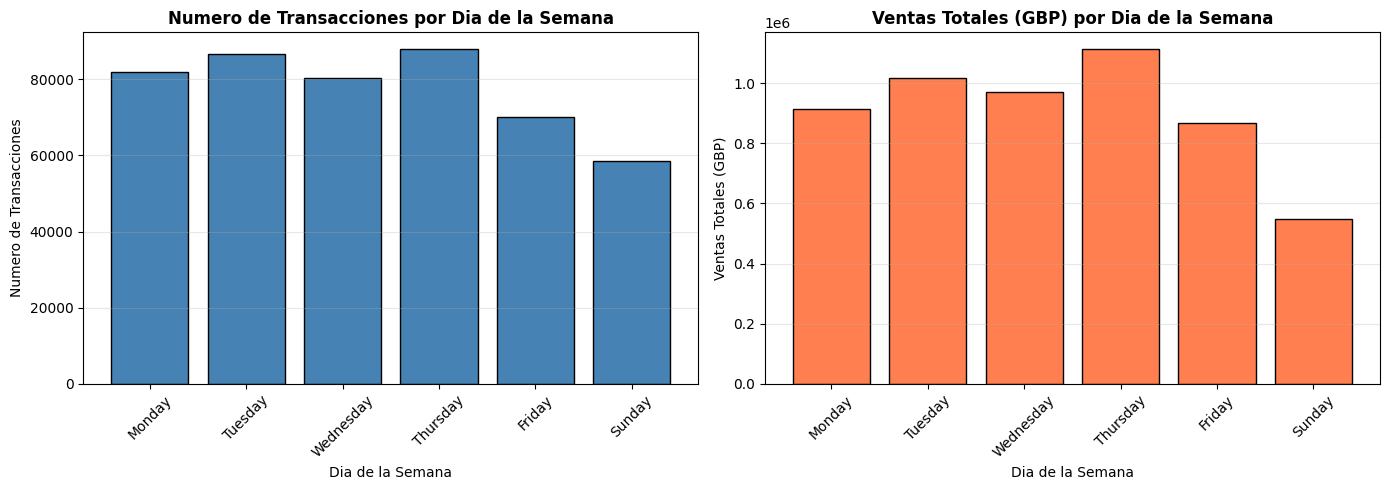

Visualizacion 1 completada (matplotlib)

VISUALIZACION 2: SEABORN - TOP 10 PAISES POR VENTAS

Top 10 paises por ventas:
          Country  num_transacciones   venta_total  ticket_promedio
0  United Kingdom             429978  4.755730e+06        11.060402
1         Germany               7682  1.451701e+05        18.897438
2          France               7206  1.287203e+05        17.862938
3            Eire               6276  1.242886e+05        19.803794
4     Switzerland               1640  3.294053e+04        20.085689
5           Spain               2128  3.133509e+04        14.725136
6         Belgium               1694  2.845024e+04        16.794711
7        Portugal               1333  2.145978e+04        16.098860
8          Norway                804  1.936386e+04        24.084403
9     Netherlands                653  1.852370e+04        28.367075



/home/spark-743d807b-f411-4a85-b104-34/.ipykernel/4307/command-8742658131258601-2382134336:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_pais, x="venta_total", y="Country",
/home/spark-743d807b-f411-4a85-b104-34/.ipykernel/4307/command-8742658131258601-2382134336:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_pais, x="ticket_promedio", y="Country",


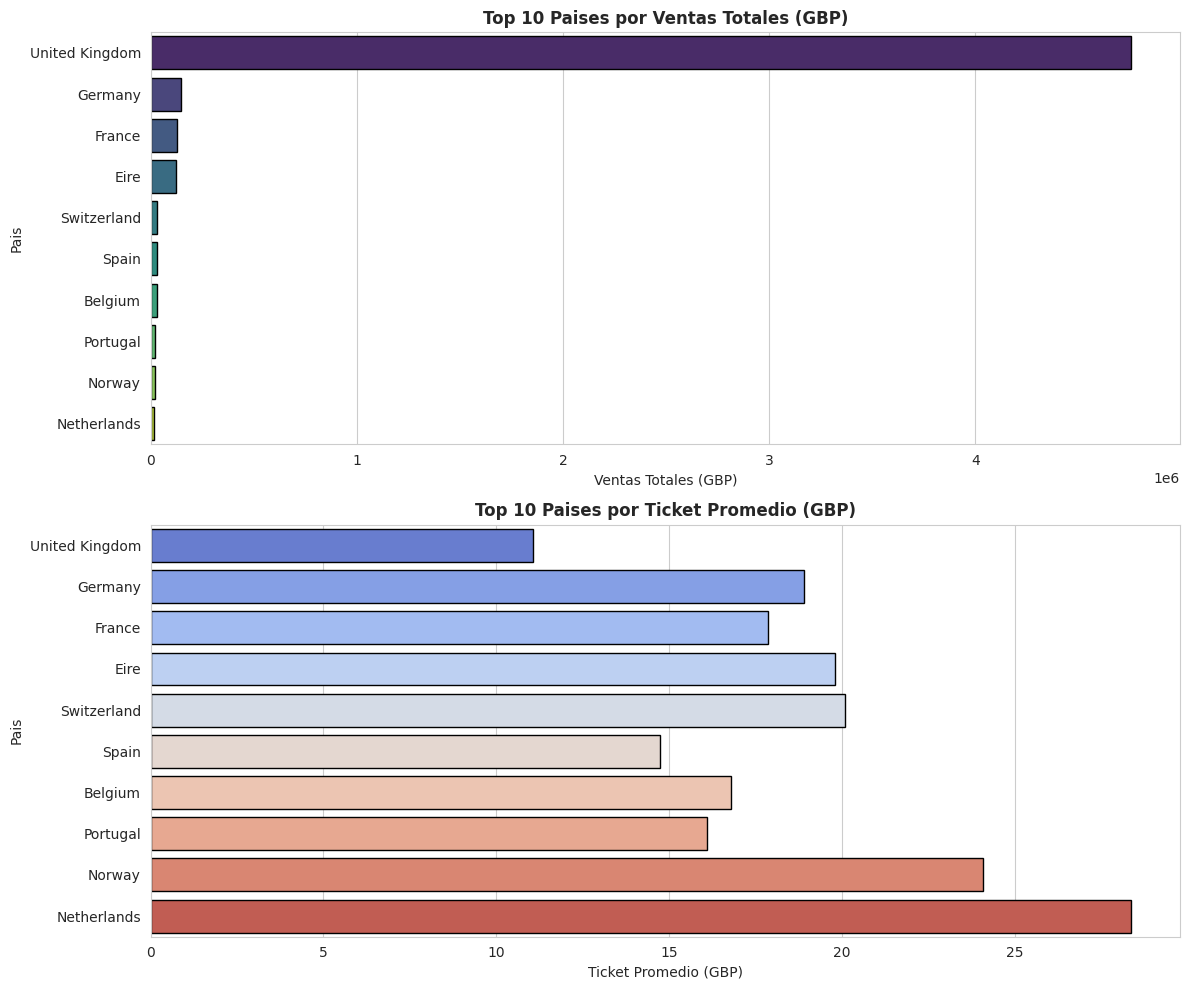

Visualizacion 2 completada (seaborn)

VISUALIZACION 3: PLOTLY - VENTAS MENSUALES POR ANO

Datos mensuales agregados:
    anio  mes  num_transacciones  venta_total  clientes_unicos  periodo
0   2010   12              35385   403191.640              837  2010-12
1   2011    1              30210   324651.080              703  2011-01
2   2011    2              23520   278648.260              706  2011-02
3   2011    3              31065   361105.890              921  2011-03
4   2011    4              25521   296161.241              808  2011-04
5   2011    5              31365   401720.850             1005  2011-05
6   2011    6              31257   365465.910              942  2011-06
7   2011    7              34183   375318.331              905  2011-07
8   2011    8              30010   378258.670              882  2011-08
9   2011    9              43466   565752.362             1200  2011-09
10  2011   10              52692   620014.850             1324  2011-10
11  2011   11      

Visualizacion 3 completada (plotly interactivo)

VISUALIZACION 4: SEABORN - HEATMAP DIA DE SEMANA VS MES

Tabla pivote para heatmap:
mes               1         2         3   ...         10         11         12
nombre_dia                                ...                                 
Monday      69320.01  50656.17  55684.18  ...  142342.21  116506.82  120384.08
Tuesday     54378.28  55793.90  86786.43  ...  115053.99  166131.56   92270.16
Wednesday   53915.12  55060.35  63454.02  ...   95255.57  175024.55  106010.88
Thursday    61060.00  51219.56  76038.38  ...  112648.05  137461.37  156431.66
Friday      58681.89  45927.78  48670.26  ...   84767.07  123946.97  120228.95
Sunday      27295.78  19990.50  30472.62  ...   69947.96   97603.58   54150.24

[6 rows x 12 columns]



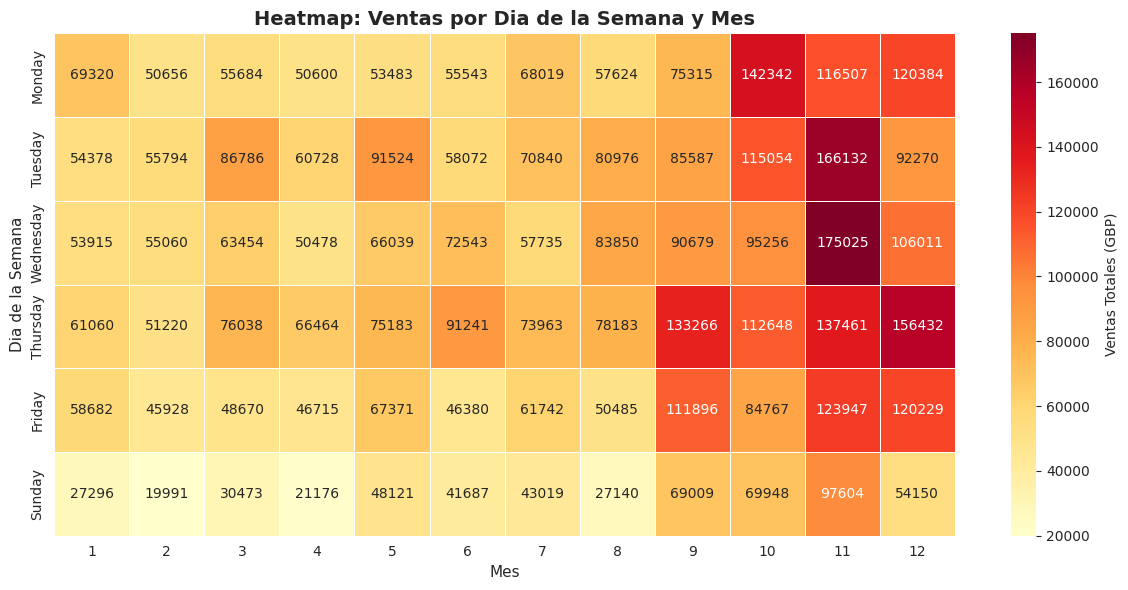

Visualizacion 4 completada (seaborn heatmap)



In [0]:
# ======================================================================
# ACTIVIDAD 3 -  VISUALIZACIONES CON LIBRERIAS
# ======================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
from pyspark.sql import functions as F

print("="*70)
print(" VISUALIZACIONES POR AGRUPACIONES CATEGORICAS")
print("="*70)
print()

# Cargar tabla limpia
tabla_limpia = "workspace.default.online_retail_clean"
df = spark.table(tabla_limpia)

print("PASO 1: PREPARACION DE DATOS PARA VISUALIZACIONES")
print("-"*70)
print(f"Tabla origen: {tabla_limpia}")
print(f"Registros cargados: {df.count():,}")
print()

# Crear columna de venta total
df = df.withColumn("venta_total", F.col("Quantity") * F.col("UnitPrice"))

# ======================================================================
# VISUALIZACION 1: MATPLOTLIB - VENTAS POR DIA DE LA SEMANA
# ======================================================================

print("="*70)
print("VISUALIZACION 1: MATPLOTLIB - DISTRIBUCION POR DIA DE LA SEMANA")
print("="*70)
print()

# Agregar datos por día de la semana
ventas_por_dia = df.groupBy("dia_semana", "nombre_dia") \
    .agg(
        F.count("*").alias("num_transacciones"),
        F.sum("venta_total").alias("venta_total")
    ) \
    .orderBy("dia_semana") \
    .toPandas()

print("Datos agregados:")
print(ventas_por_dia)
print()

# Crear visualización con matplotlib
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Número de transacciones por día
axes[0].bar(ventas_por_dia["nombre_dia"], ventas_por_dia["num_transacciones"], 
            color='steelblue', edgecolor='black')
axes[0].set_title("Numero de Transacciones por Dia de la Semana", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Dia de la Semana", fontsize=10)
axes[0].set_ylabel("Numero de Transacciones", fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Ventas totales por día
axes[1].bar(ventas_por_dia["nombre_dia"], ventas_por_dia["venta_total"], 
            color='coral', edgecolor='black')
axes[1].set_title("Ventas Totales (GBP) por Dia de la Semana", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Dia de la Semana", fontsize=10)
axes[1].set_ylabel("Ventas Totales (GBP)", fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizacion 1 completada (matplotlib)")
print()

# ======================================================================
# VISUALIZACION 2: SEABORN - TOP PAISES POR VENTAS
# ======================================================================

print("="*70)
print("VISUALIZACION 2: SEABORN - TOP 10 PAISES POR VENTAS")
print("="*70)
print()

# Agregar datos por país
ventas_por_pais = df.groupBy("Country") \
    .agg(
        F.count("*").alias("num_transacciones"),
        F.sum("venta_total").alias("venta_total"),
        F.avg("venta_total").alias("ticket_promedio")
    ) \
    .orderBy(F.desc("venta_total")) \
    .limit(10) \
    .toPandas()

print("Top 10 paises por ventas:")
print(ventas_por_pais)
print()

# Configurar estilo de seaborn
sns.set_style("whitegrid")

# Crear visualización con seaborn
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Ventas totales por país
sns.barplot(data=ventas_por_pais, x="venta_total", y="Country", 
            palette="viridis", ax=axes[0], edgecolor='black')
axes[0].set_title("Top 10 Paises por Ventas Totales (GBP)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Ventas Totales (GBP)", fontsize=10)
axes[0].set_ylabel("Pais", fontsize=10)

# Gráfico 2: Ticket promedio por país
sns.barplot(data=ventas_por_pais, x="ticket_promedio", y="Country", 
            palette="coolwarm", ax=axes[1], edgecolor='black')
axes[1].set_title("Top 10 Paises por Ticket Promedio (GBP)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Ticket Promedio (GBP)", fontsize=10)
axes[1].set_ylabel("Pais", fontsize=10)

plt.tight_layout()
plt.show()

print("Visualizacion 2 completada (seaborn)")
print()

# ======================================================================
# VISUALIZACION 3: PLOTLY - VENTAS MENSUALES INTERACTIVAS
# ======================================================================

print("="*70)
print("VISUALIZACION 3: PLOTLY - VENTAS MENSUALES POR ANO")
print("="*70)
print()

# Agregar datos por año y mes
ventas_mensuales = df.groupBy("anio", "mes") \
    .agg(
        F.count("*").alias("num_transacciones"),
        F.sum("venta_total").alias("venta_total"),
        F.countDistinct("CustomerID").alias("clientes_unicos")
    ) \
    .orderBy("anio", "mes") \
    .toPandas()

# Crear columna de período para mejor visualización
ventas_mensuales["periodo"] = ventas_mensuales["anio"].astype(str) + "-" + \
                               ventas_mensuales["mes"].astype(str).str.zfill(2)

print("Datos mensuales agregados:")
print(ventas_mensuales)
print()

# Crear visualización interactiva con plotly
fig = px.line(ventas_mensuales, 
              x="periodo", 
              y="venta_total",
              markers=True,
              title="Evolucion de Ventas Mensuales (2010-2011)",
              labels={"periodo": "Periodo (Ano-Mes)", 
                      "venta_total": "Ventas Totales (GBP)"},
              color_discrete_sequence=["#1f77b4"])

fig.update_traces(line=dict(width=3), marker=dict(size=8))
fig.update_layout(
    xaxis_tickangle=-45,
    hovermode='x unified',
    plot_bgcolor='white',
    font=dict(size=11)
)
fig.show()

print("Visualizacion 3 completada (plotly interactivo)")
print()

# ======================================================================
# VISUALIZACION 4: SEABORN - HEATMAP DE VENTAS
# ======================================================================

print("="*70)
print("VISUALIZACION 4: SEABORN - HEATMAP DIA DE SEMANA VS MES")
print("="*70)
print()

# Crear tabla pivote para heatmap
ventas_heatmap = df.groupBy("mes", "dia_semana", "nombre_dia") \
    .agg(F.sum("venta_total").alias("venta_total")) \
    .toPandas()

# Crear pivote
pivot_ventas = ventas_heatmap.pivot_table(
    index="nombre_dia",
    columns="mes",
    values="venta_total",
    aggfunc="sum"
)

# Ordenar días de la semana correctamente
dias_ordenados = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]
pivot_ventas = pivot_ventas.reindex(dias_ordenados)

print("Tabla pivote para heatmap:")
print(pivot_ventas)
print()

# Crear heatmap con seaborn
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ventas, 
            annot=True, 
            fmt=".0f", 
            cmap="YlOrRd", 
            linewidths=0.5,
            cbar_kws={'label': 'Ventas Totales (GBP)'})
plt.title("Heatmap: Ventas por Dia de la Semana y Mes", fontsize=14, fontweight='bold')
plt.xlabel("Mes", fontsize=11)
plt.ylabel("Dia de la Semana", fontsize=11)
plt.tight_layout()
plt.show()

print("Visualizacion 4 completada (seaborn heatmap)")
print()



In [0]:
# ======================================================================
# EQUIVALENCIAS PYSPARK Y SQL
# ======================================================================

from pyspark.sql import functions as F

print("="*70)
print("DEMOSTRACION: EQUIVALENCIAS ENTRE PYSPARK Y SQL")
print("="*70)
print()
print("Esta seccion demuestra que las mismas operaciones pueden realizarse")
print("tanto en PySpark (enfoque programatico) como en SQL (enfoque declarativo)")
print()

# Registrar la tabla como vista temporal para consultas SQL
df = spark.table("workspace.default.online_retail_clean")
df.createOrReplaceTempView("online_retail_sql")

print(f"Tabla registrada como vista: online_retail_sql")
print(f"Registros disponibles: {df.count():,}")
print()

# ======================================================================
# EJEMPLO 1: TRANSFORMACION - COLUMNAS DERIVADAS DE FECHA
# ======================================================================

print("="*70)
print("EJEMPLO 1: TRANSFORMACION - COLUMNAS DERIVADAS DE FECHA")
print("="*70)
print()

# PYSPARK: Transformación
print("ENFOQUE PYSPARK:")
print("-"*70)
print("Codigo:")
print("""
df_pyspark = df.select(
    "InvoiceNo",
    "InvoiceDate",
    F.to_date("InvoiceDate").alias("fecha"),
    F.year("InvoiceDate").alias("anio"),
    F.month("InvoiceDate").alias("mes"),
    F.dayofmonth("InvoiceDate").alias("dia"),
    F.date_format("InvoiceDate", "EEEE").alias("nombre_dia")
).limit(5)
""")
print()

df_pyspark = df.select(
    "InvoiceNo",
    "InvoiceDate",
    F.to_date("InvoiceDate").alias("fecha"),
    F.year("InvoiceDate").alias("anio"),
    F.month("InvoiceDate").alias("mes"),
    F.dayofmonth("InvoiceDate").alias("dia"),
    F.date_format("InvoiceDate", "EEEE").alias("nombre_dia")
).limit(5)

print("Resultado PySpark:")
df_pyspark.show(truncate=False)

print()
print("ENFOQUE SQL:")
print("-"*70)
print("Codigo:")
print("""
SELECT 
    InvoiceNo,
    InvoiceDate,
    DATE(InvoiceDate) AS fecha,
    YEAR(InvoiceDate) AS anio,
    MONTH(InvoiceDate) AS mes,
    DAY(InvoiceDate) AS dia,
    DATE_FORMAT(InvoiceDate, 'EEEE') AS nombre_dia
FROM online_retail_sql
LIMIT 5
""")
print()

df_sql = spark.sql("""
    SELECT 
        InvoiceNo,
        InvoiceDate,
        DATE(InvoiceDate) AS fecha,
        YEAR(InvoiceDate) AS anio,
        MONTH(InvoiceDate) AS mes,
        DAY(InvoiceDate) AS dia,
        DATE_FORMAT(InvoiceDate, 'EEEE') AS nombre_dia
    FROM online_retail_sql
    LIMIT 5
""")

print("Resultado SQL:")
df_sql.show(truncate=False)

# ======================================================================
# EJEMPLO 2: AGREGACION - RESUMEN MENSUAL DE VENTAS
# ======================================================================

print("="*70)
print("EJEMPLO 2: AGREGACION - RESUMEN MENSUAL DE VENTAS")
print("="*70)
print()

# PYSPARK: Agregación
print("ENFOQUE PYSPARK:")
print("-"*70)
print("Codigo:")
print("""
df_pyspark_agg = df.withColumn("venta_total", F.col("Quantity") * F.col("UnitPrice"))
resumen_pyspark = df_pyspark_agg.groupBy(
    F.year("InvoiceDate").alias("anio"),
    F.month("InvoiceDate").alias("mes")
).agg(
    F.count("*").alias("n_registros"),
    F.countDistinct("InvoiceNo").alias("n_facturas_unicas"),
    F.countDistinct("CustomerID").alias("n_clientes_unicos"),
    F.sum("Quantity").alias("cantidad_total"),
    F.round(F.sum("venta_total"), 2).alias("venta_total_gbp"),
    F.round(F.avg("UnitPrice"), 2).alias("precio_promedio")
).orderBy("anio", "mes")
""")
print()

df_pyspark_agg = df.withColumn("venta_total", F.col("Quantity") * F.col("UnitPrice"))
resumen_pyspark = df_pyspark_agg.groupBy(
    F.year("InvoiceDate").alias("anio"),
    F.month("InvoiceDate").alias("mes")
).agg(
    F.count("*").alias("n_registros"),
    F.countDistinct("InvoiceNo").alias("n_facturas_unicas"),
    F.countDistinct("CustomerID").alias("n_clientes_unicos"),
    F.sum("Quantity").alias("cantidad_total"),
    F.round(F.sum("venta_total"), 2).alias("venta_total_gbp"),
    F.round(F.avg("UnitPrice"), 2).alias("precio_promedio")
).orderBy("anio", "mes")

print("Resultado PySpark (primeros 10 meses):")
resumen_pyspark.show(10, truncate=False)

print()
print("ENFOQUE SQL:")
print("-"*70)
print("Codigo:")
print("""
SELECT 
    YEAR(InvoiceDate) AS anio,
    MONTH(InvoiceDate) AS mes,
    COUNT(*) AS n_registros,
    COUNT(DISTINCT InvoiceNo) AS n_facturas_unicas,
    COUNT(DISTINCT CustomerID) AS n_clientes_unicos,
    SUM(Quantity) AS cantidad_total,
    ROUND(SUM(Quantity * UnitPrice), 2) AS venta_total_gbp,
    ROUND(AVG(UnitPrice), 2) AS precio_promedio
FROM online_retail_sql
GROUP BY YEAR(InvoiceDate), MONTH(InvoiceDate)
ORDER BY anio, mes
LIMIT 10
""")
print()

resumen_sql = spark.sql("""
    SELECT 
        YEAR(InvoiceDate) AS anio,
        MONTH(InvoiceDate) AS mes,
        COUNT(*) AS n_registros,
        COUNT(DISTINCT InvoiceNo) AS n_facturas_unicas,
        COUNT(DISTINCT CustomerID) AS n_clientes_unicos,
        SUM(Quantity) AS cantidad_total,
        ROUND(SUM(Quantity * UnitPrice), 2) AS venta_total_gbp,
        ROUND(AVG(UnitPrice), 2) AS precio_promedio
    FROM online_retail_sql
    GROUP BY YEAR(InvoiceDate), MONTH(InvoiceDate)
    ORDER BY anio, mes
    LIMIT 10
""")

print("Resultado SQL (primeros 10 meses):")
resumen_sql.show(10, truncate=False)


# ======================================================================
# EJEMPLO 3: FILTRADO Y ORDENAMIENTO
# ======================================================================

print("="*70)
print("EJEMPLO 3: FILTRADO Y ORDENAMIENTO - TOP 5 PAISES")
print("="*70)
print()

# PYSPARK: Filtrado
print("ENFOQUE PYSPARK:")
print("-"*70)
print("Codigo:")
print("""
top_paises_pyspark = (df
    .withColumn("venta_total", F.col("Quantity") * F.col("UnitPrice"))
    .groupBy("Country")
    .agg(
        F.count("*").alias("transacciones"),
        F.round(F.sum("venta_total"), 2).alias("ventas_gbp")
    )
    .orderBy(F.desc("ventas_gbp"))
    .limit(5)
)
""")
print()

top_paises_pyspark = (df
    .withColumn("venta_total", F.col("Quantity") * F.col("UnitPrice"))
    .groupBy("Country")
    .agg(
        F.count("*").alias("transacciones"),
        F.round(F.sum("venta_total"), 2).alias("ventas_gbp")
    )
    .orderBy(F.desc("ventas_gbp"))
    .limit(5)
)

print("Resultado PySpark:")
top_paises_pyspark.show(truncate=False)

print()
print("ENFOQUE SQL:")
print("-"*70)
print("Codigo:")
print("""
SELECT 
    Country,
    COUNT(*) AS transacciones,
    ROUND(SUM(Quantity * UnitPrice), 2) AS ventas_gbp
FROM online_retail_sql
GROUP BY Country
ORDER BY ventas_gbp DESC
LIMIT 5
""")
print()

top_paises_sql = spark.sql("""
    SELECT 
        Country,
        COUNT(*) AS transacciones,
        ROUND(SUM(Quantity * UnitPrice), 2) AS ventas_gbp
    FROM online_retail_sql
    GROUP BY Country
    ORDER BY ventas_gbp DESC
    LIMIT 5
""")

print("Resultado SQL:")
top_paises_sql.show(truncate=False)




DEMOSTRACION: EQUIVALENCIAS ENTRE PYSPARK Y SQL

Esta seccion demuestra que las mismas operaciones pueden realizarse
tanto en PySpark (enfoque programatico) como en SQL (enfoque declarativo)

Tabla registrada como vista: online_retail_sql
Registros disponibles: 465,535

EJEMPLO 1: TRANSFORMACION - COLUMNAS DERIVADAS DE FECHA

ENFOQUE PYSPARK:
----------------------------------------------------------------------
Codigo:

df_pyspark = df.select(
    "InvoiceNo",
    "InvoiceDate",
    F.to_date("InvoiceDate").alias("fecha"),
    F.year("InvoiceDate").alias("anio"),
    F.month("InvoiceDate").alias("mes"),
    F.dayofmonth("InvoiceDate").alias("dia"),
    F.date_format("InvoiceDate", "EEEE").alias("nombre_dia")
).limit(5)


Resultado PySpark:
+---------+-------------------+----------+----+---+---+----------+
|InvoiceNo|InvoiceDate        |fecha     |anio|mes|dia|nombre_dia|
+---------+-------------------+----------+----+---+---+----------+
|536365   |2010-12-01 08:26:00|2010-12-01|2010|1

---

## Video Explicativo de la Actividad Número 3

A continuación se encuentra el enlace al video explicativo de la Actividad 3:

**Video explicativo:** [https://drive.google.com/file/d/13faM3VciRm9vJ4OzyGx8mDMxsSx06CIp/view?usp=sharing](https://drive.google.com/file/d/13faM3VciRm9vJ4OzyGx8mDMxsSx06CIp/view?usp=sharing)

---

## Repositorio de GitHub

**Repositorio del proyecto:** [https://github.com/jesusjoelgonca/bigdata-2025-02.git](https://github.com/jesusjoelgonca/bigdata-2025-02.git)
